# 🔐 Predictive Modeling of Crypto-System Vulnerabilities
## End-to-End Machine Learning Pipeline
**Authors:** Eileen Rashduni · Atharv Koratkar

This notebook walks through every stage of the pipeline:

| Stage | Description |
|-------|-------------|
| **Stage 1** | Data Ingestion — load & harmonise all 6 real datasets |
| **Stage 2** | EDA — visualise raw breach data |
| **Stage 3** | Feature Engineering — build model-ready feature matrix |
| **Stage 4** | Feature Analysis — correlation, distribution, importance |
| **Stage 5** | Walk-Forward Model Training — 5 models × time-series CV |
| **Stage 6** | Evaluation — Brier Score, Log-Loss, PR-AUC |
| **Stage 7** | Explainability — feature importance & SHAP-style analysis |
| **Stage 8** | Risk Scoring — probability output & alert tier |


## ⚙️ Setup

In [109]:
import sys, os, warnings
warnings.filterwarnings('ignore')

# Add project root to path
sys.path.insert(0, os.path.dirname(os.path.abspath('')))

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from IPython.display import display, HTML

# Inline plotting
%matplotlib inline
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 10,
})

PALETTE = ['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd','#8c564b','#e377c2']
print('Environment ready ✓')
print(f'  numpy  {np.__version__}')
print(f'  pandas {pd.__version__}')
import sklearn; print(f'  sklearn {sklearn.__version__}')


Environment ready ✓
  numpy  2.4.3
  pandas 3.0.1
  sklearn 1.8.0


---
## 📥 Stage 1 — Data Ingestion

We load and harmonise **6 independent datasets**:

| ID | Source | Records | Description |
|----|--------|---------|-------------|
| IIB | Information is Beautiful | ~440 | High-profile global breaches 2004–2022 |
| HHS | HHS / OCR | ~1 285 | US Healthcare breaches 2009–present |
| DBN | DataBreachN | ~352 | International, country-level |
| DBEN | DataBreach EU | ~277 | European registry 2004–2017 |
| DF1 | Wikipedia Extended | ~352 | Broad entity list |
| CSIS | CSIS PDF | text-mined | State-sponsored / major incidents 2006–2025 |


In [110]:
from data_ingestion import load_all_datasets, flag_crypto, categorise_method

df = load_all_datasets(data_dir='data')

print(f'\n✅ Total records loaded: {len(df):,}')
print(f'   Year range:           {df["year"].min()} – {df["year"].max()}')
print(f'   Crypto-related:       {df["is_crypto"].sum():,} ({df["is_crypto"].mean()*100:.1f}%)')
print(f'   Source breakdown:')
print(df['source_id'].value_counts().to_string())


  pypdf extraction error: cryptography>=3.1 is required for AES algorithm



✅ Total records loaded: 19,964
   Year range:           2004 – 2026
   Crypto-related:       1,650 (8.3%)
   Source breakdown:
source_id
CE      15949
WA       1506
HHS       883
DHL       685
IIB       416
DBN       273
CSIS      207
DBEN       37
DF1         8


In [111]:
# Preview the unified DataFrame
display(HTML('<b>Unified Breach DataFrame (first 10 rows)</b>'))
display(df.head(10).style.background_gradient(subset=['records_affected'], cmap='Blues'))


,year,entity,sector_raw,sector,method_raw,method_category,records_affected,is_crypto,source_id
0,2022,Plex,web,tech_web,hacked,hacking,15000000.000000,False,IIB
1,2021,Twitter,web,tech_web,hacked,hacking,5400000.000000,False,IIB
2,2022,Shanghai Police,financial,financial,hacked,hacking,500000000.000000,False,IIB
3,2022,"City of Amagasaki, Japan",government,government,oops!,poor_security,500000.000000,False,IIB
4,2022,Dubai Real Estate Leak,financial,financial,inside job,insider,800000.000000,False,IIB
5,2022,Heroku,tech,tech_web,hacked,hacking,50000.000000,True,IIB
6,2022,Mailchimp,tech,tech_web,hacked,hacking,106586.000000,False,IIB
7,2022,PayHere,financial,financial,hacked,hacking,1580249.000000,False,IIB
8,2022,CDEK,retail,retail,hacked,hacking,18218203.000000,False,IIB
9,2022,Washington State Dpt of Licensing,government,government,hacked,hacking,257000.000000,False,IIB


In [112]:
# Data quality summary
print('=== Data Quality ===')
print(df.dtypes.to_string())
print('\nNull counts:')
print(df.isnull().sum().to_string())
print(f'\nMethod categories: {sorted(df["method_category"].unique())}')
print(f'Sectors:           {sorted(df["sector"].unique())}')


=== Data Quality ===
year                  int64
entity                  str
sector_raw              str
sector                  str
method_raw              str
method_category         str
records_affected    float64
is_crypto              bool
source_id               str

Null counts:
year                    0
entity                  0
sector_raw              0
sector                  0
method_raw              0
method_category         0
records_affected    16614
is_crypto               0
source_id               0

Method categories: ['ddos', 'hacking', 'insider', 'lost_device', 'malware', 'other', 'phishing', 'poor_security', 'smart_contract_exploit', 'supply_chain', 'unauthorized_access']
Sectors:           ['academic', 'energy', 'financial', 'gaming', 'government', 'healthcare', 'legal', 'media', 'other', 'retail', 'social_media', 'tech_web', 'telecom', 'transport', 'unknown']


---
## 📊 Stage 2 — Exploratory Data Analysis

Visualise the raw breach landscape before any feature engineering.


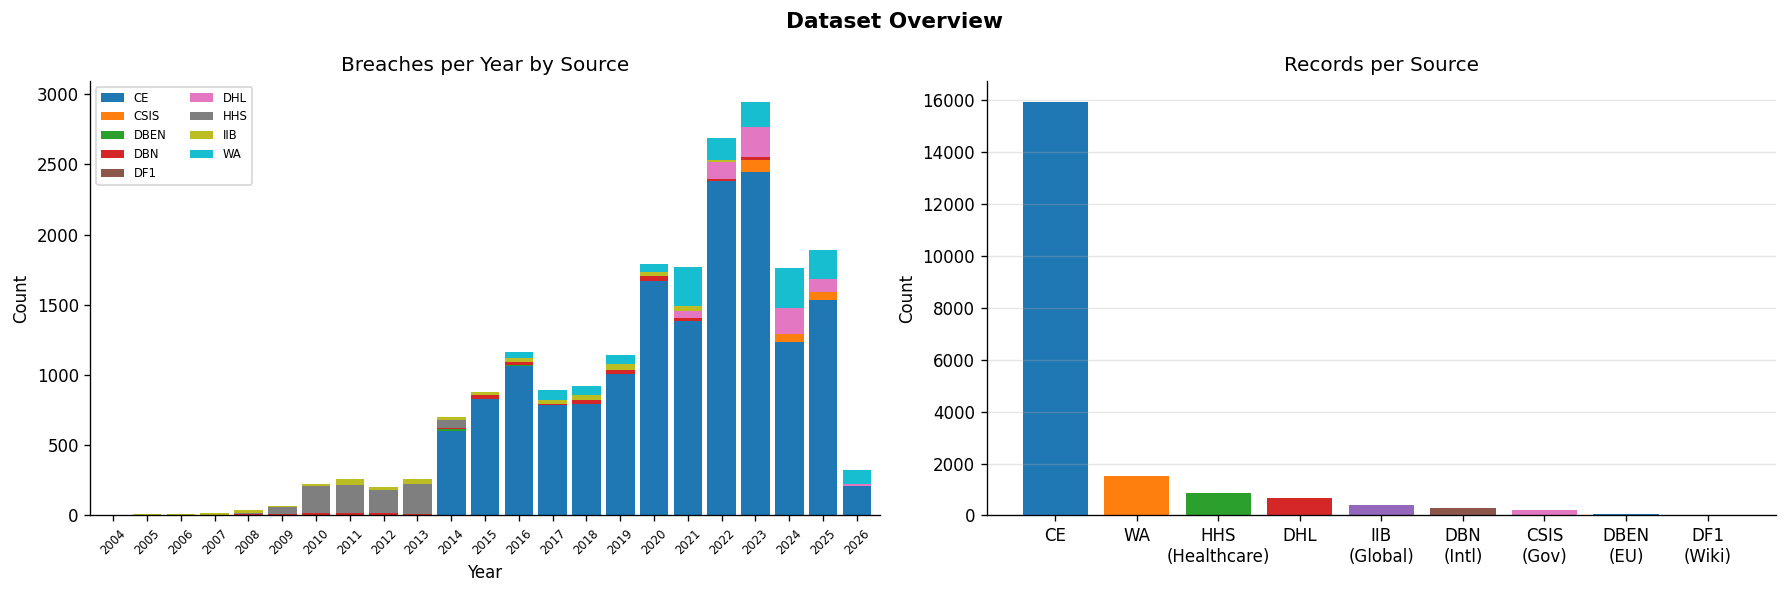

In [113]:
# ── 2A: Breach counts by year, coloured by source ──────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Dataset Overview', fontsize=13, fontweight='bold')

yr_src = df.groupby(['year','source_id']).size().unstack(fill_value=0)
yr_src.plot(kind='bar', stacked=True, ax=axes[0],
            colormap='tab10', legend=True, width=0.85)
axes[0].set_title('Breaches per Year by Source')
axes[0].set_xlabel('Year'); axes[0].set_ylabel('Count')
axes[0].legend(fontsize=7, ncol=2)
axes[0].tick_params(axis='x', rotation=45, labelsize=7)

src_cnt = df['source_id'].value_counts()
src_labels = {'IIB':'IIB\n(Global)','HHS':'HHS\n(Healthcare)',
              'DBN':'DBN\n(Intl)','DBEN':'DBEN\n(EU)',
              'DF1':'DF1\n(Wiki)','CSIS':'CSIS\n(Gov)'}
axes[1].bar([src_labels.get(s,s) for s in src_cnt.index],
            src_cnt.values, color=PALETTE)
axes[1].set_title('Records per Source'); axes[1].set_ylabel('Count')
axes[1].grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()


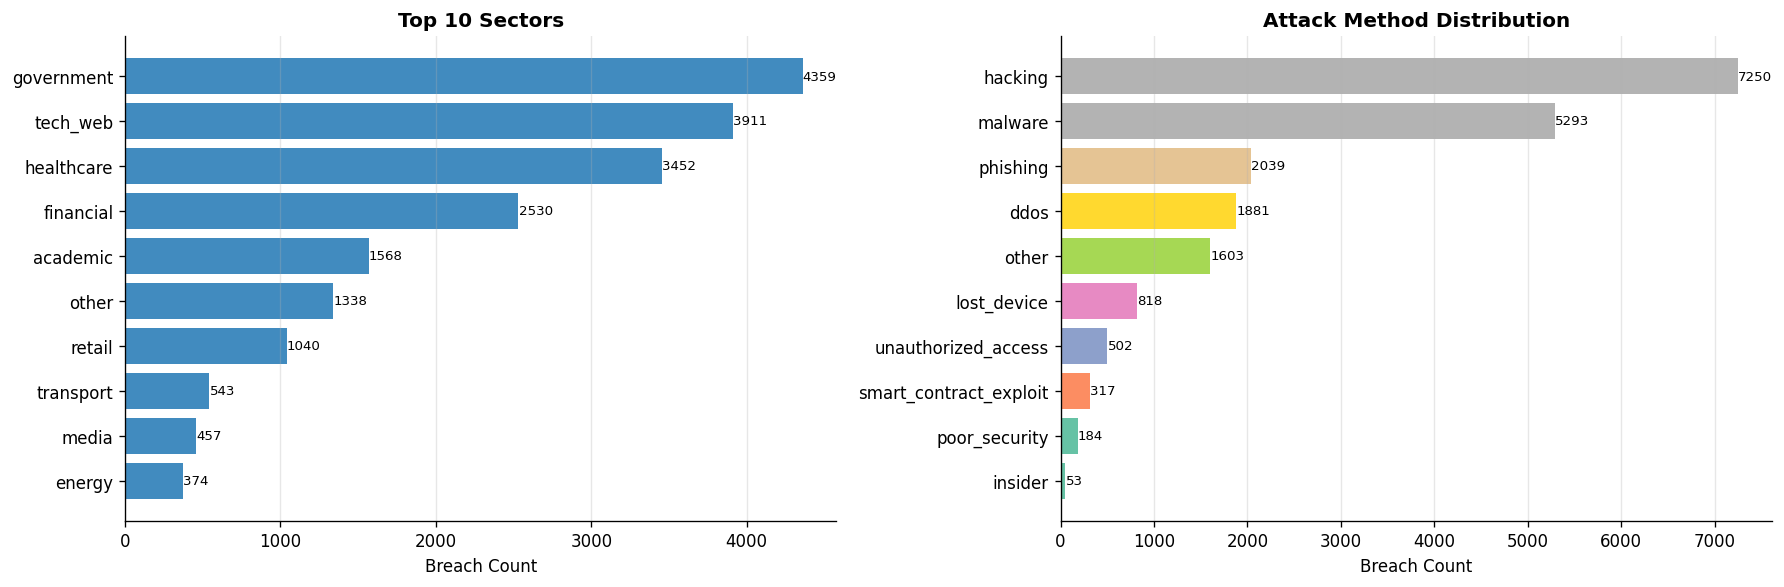

In [114]:
# ── 2B: Sector & Method distributions ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sec = df['sector'].value_counts().head(10)
axes[0].barh(sec.index[::-1], sec.values[::-1], color='#1f77b4', alpha=0.85)
axes[0].set_title('Top 10 Sectors', fontweight='bold')
axes[0].set_xlabel('Breach Count'); axes[0].grid(axis='x', alpha=0.3)
for i, v in enumerate(sec.values[::-1]):
    axes[0].text(v+2, i, str(v), va='center', fontsize=8)

meth = df['method_category'].value_counts().head(10)
colours = plt.cm.Set2(np.linspace(0, 1, len(meth)))
axes[1].barh(meth.index[::-1], meth.values[::-1], color=colours)
axes[1].set_title('Attack Method Distribution', fontweight='bold')
axes[1].set_xlabel('Breach Count'); axes[1].grid(axis='x', alpha=0.3)
for i, v in enumerate(meth.values[::-1]):
    axes[1].text(v+2, i, str(v), va='center', fontsize=8)

plt.tight_layout(); plt.show()


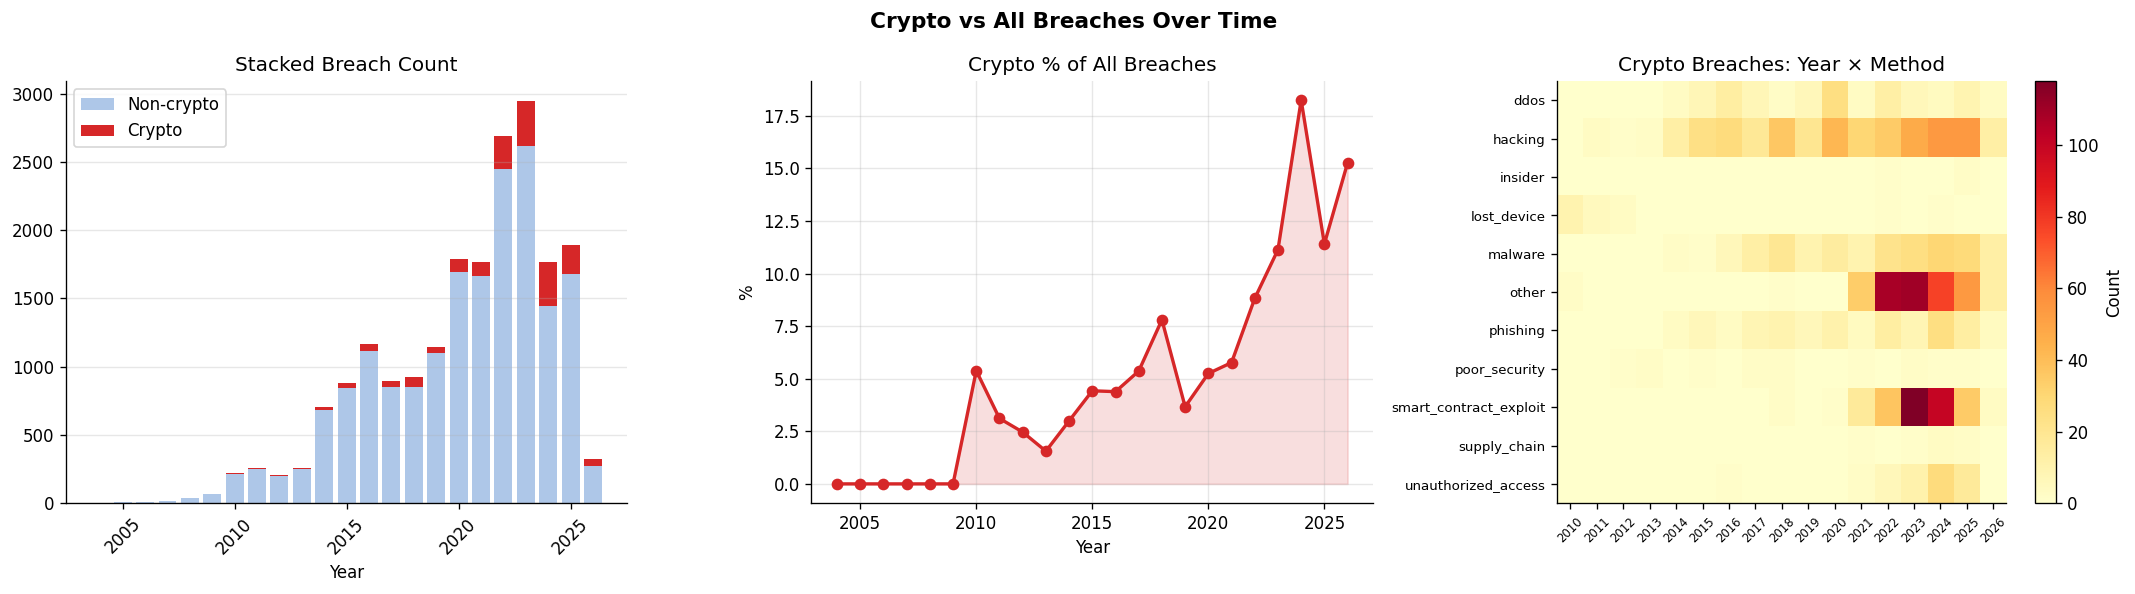

In [115]:
# ── 2C: Crypto vs Non-Crypto over time ─────────────────────────────────
yr = df.groupby('year')
total  = yr.size().rename('total')
crypto = yr['is_crypto'].sum().rename('crypto')
comb   = pd.concat([total, crypto], axis=1).fillna(0)
comb['non_crypto'] = comb['total'] - comb['crypto']

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Crypto vs All Breaches Over Time', fontsize=13, fontweight='bold')

ax1.bar(comb.index, comb['non_crypto'], label='Non-crypto', color='#aec7e8')
ax1.bar(comb.index, comb['crypto'], bottom=comb['non_crypto'],
        label='Crypto', color='#d62728')
ax1.set_title('Stacked Breach Count'); ax1.legend(); ax1.grid(axis='y', alpha=0.3)
ax1.set_xlabel('Year'); ax1.tick_params(axis='x', rotation=45)

pct = (comb['crypto'] / comb['total'].replace(0,1)) * 100
ax2.plot(pct.index, pct.values, 'o-', color='#d62728', linewidth=2)
ax2.fill_between(pct.index, pct.values, alpha=0.15, color='#d62728')
ax2.set_title('Crypto % of All Breaches'); ax2.set_ylabel('%')
ax2.set_xlabel('Year'); ax2.grid(alpha=0.3)

# Heatmap: method × year (crypto only)
crypto_df = df[df['is_crypto']]
if len(crypto_df) > 0:
    heat = crypto_df.groupby(['year','method_category']).size().unstack(fill_value=0)
    im = ax3.imshow(heat.T, aspect='auto', cmap='YlOrRd')
    ax3.set_yticks(range(len(heat.columns)))
    ax3.set_yticklabels(heat.columns, fontsize=8)
    ax3.set_xticks(range(len(heat.index)))
    ax3.set_xticklabels(heat.index, rotation=45, fontsize=7)
    ax3.set_title('Crypto Breaches: Year × Method')
    plt.colorbar(im, ax=ax3, label='Count')

plt.tight_layout(); plt.show()


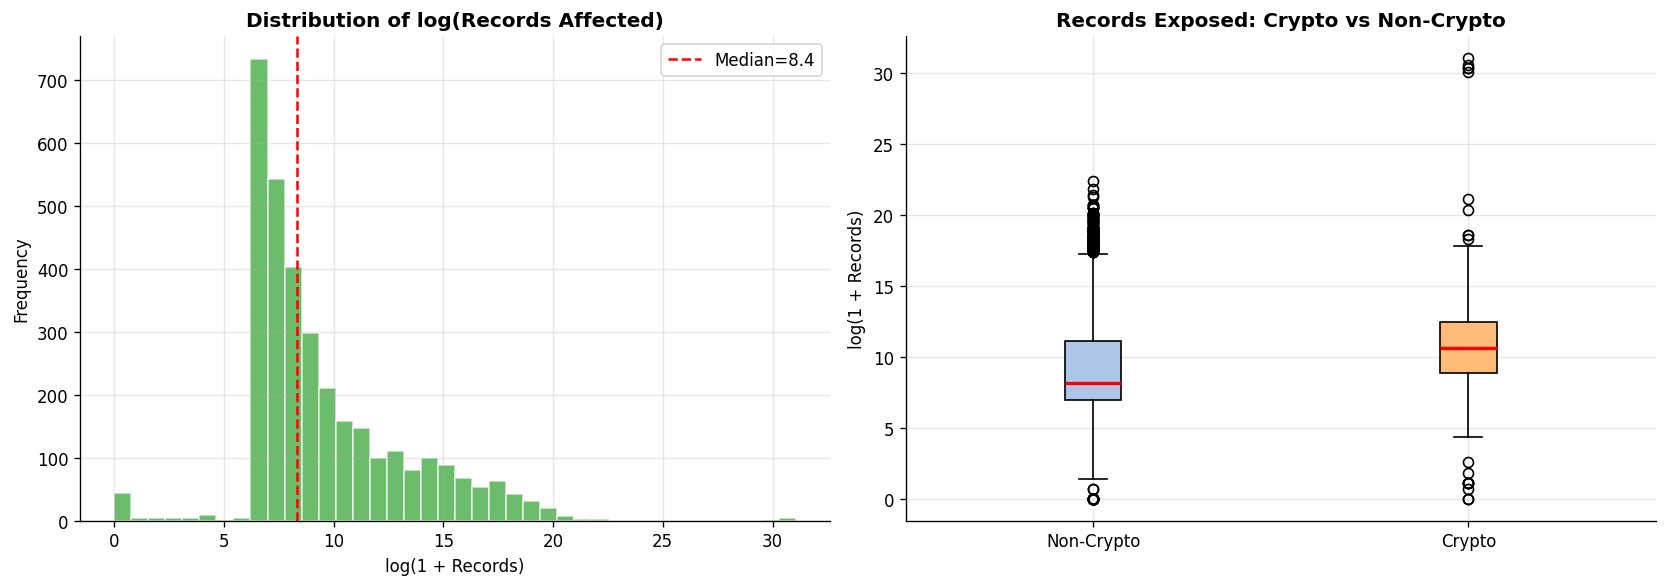

Crypto median records:     45,423,739,446
Non-crypto median records: 138,417,115


In [116]:
# ── 2D: Records exposed distribution (log scale) ───────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of log(records)
log_rec = np.log1p(df['records_affected'].dropna())
ax1.hist(log_rec, bins=40, color='#2ca02c', alpha=0.7, edgecolor='white')
ax1.set_title('Distribution of log(Records Affected)', fontweight='bold')
ax1.set_xlabel('log(1 + Records)'); ax1.set_ylabel('Frequency')
ax1.axvline(log_rec.median(), color='red', linestyle='--', label=f'Median={log_rec.median():.1f}')
ax1.legend(); ax1.grid(alpha=0.3)

# Crypto vs non-crypto record comparison (box plot)
# Cast to bool first to avoid bitwise NOT issue on mixed-type columns
is_crypto_mask = df['is_crypto'].astype(bool)
crypto_rec  = np.log1p(df[is_crypto_mask]['records_affected'].dropna())
ncrypto_rec = np.log1p(df[~is_crypto_mask]['records_affected'].dropna())
bp = ax2.boxplot([ncrypto_rec, crypto_rec],
                 labels=['Non-Crypto', 'Crypto'],
                 patch_artist=True,
                 boxprops=dict(facecolor='#aec7e8'),
                 medianprops=dict(color='red', linewidth=2))
bp['boxes'][1].set_facecolor('#ffbb78')
ax2.set_title('Records Exposed: Crypto vs Non-Crypto', fontweight='bold')
ax2.set_ylabel('log(1 + Records)'); ax2.grid(alpha=0.3)

plt.tight_layout(); plt.show()
print(f'Crypto median records:     {10**crypto_rec.median():,.0f}')
print(f'Non-crypto median records: {10**ncrypto_rec.median():,.0f}')


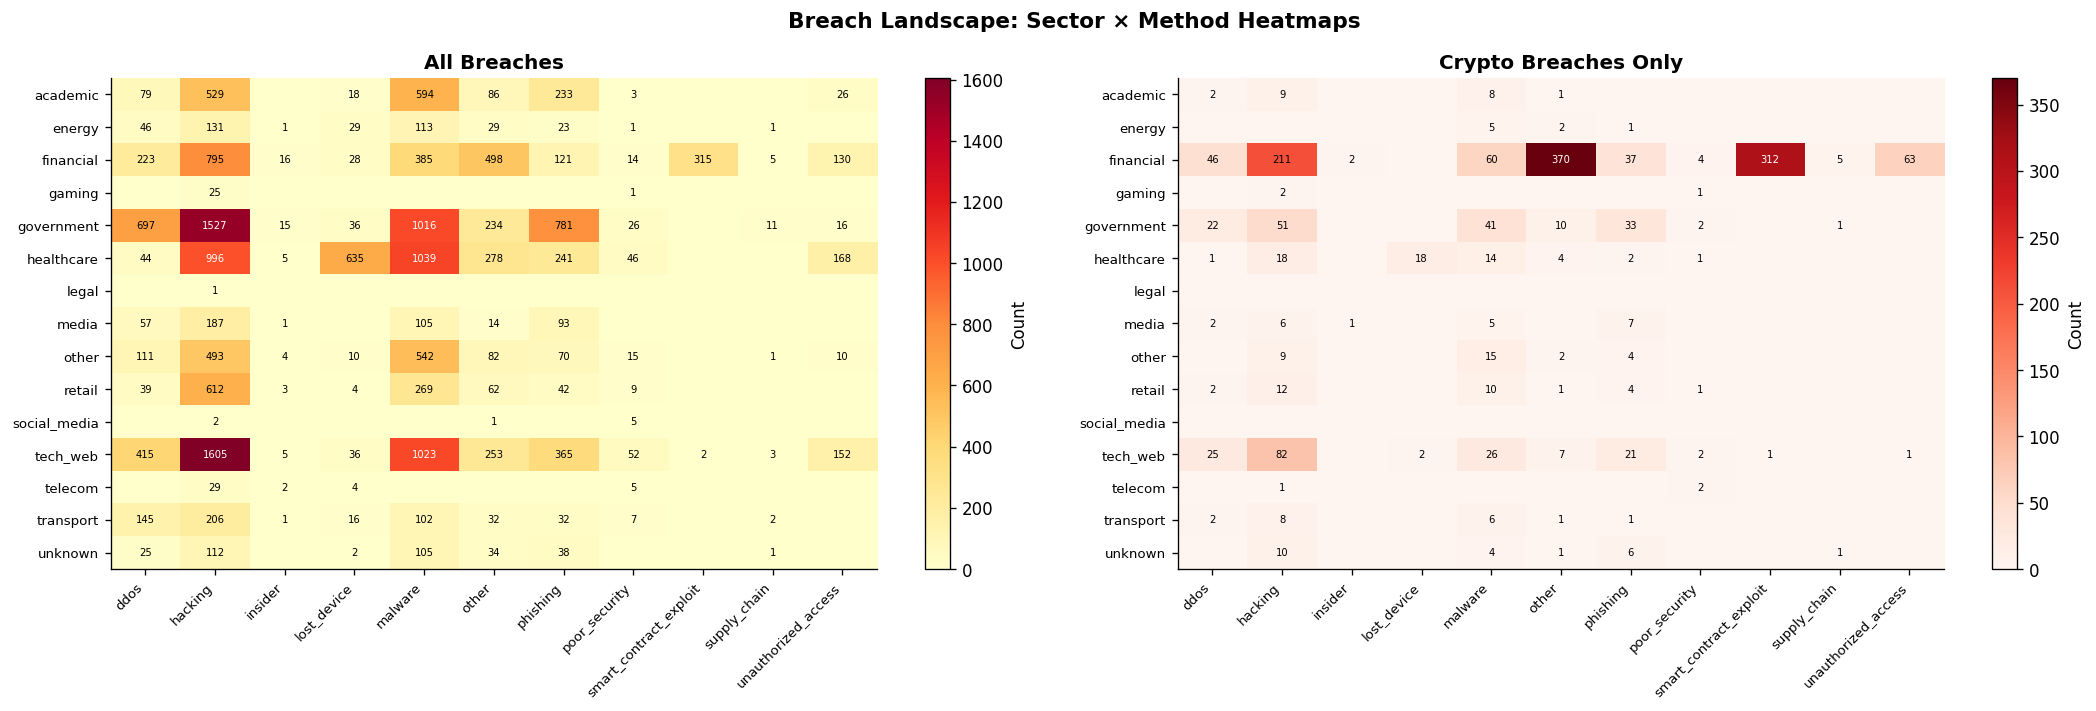

In [117]:
# ── 2E: Sector × Method heatmap (all breaches vs crypto only) ──────────
sec_meth = df.groupby(['sector', 'method_category']).size().unstack(fill_value=0)
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Breach Landscape: Sector × Method Heatmaps', fontsize=13, fontweight='bold')

for ax, sub_df, title, cmap in [
    (axes[0], df, 'All Breaches', 'YlOrRd'),
    (axes[1], df[df['is_crypto']], 'Crypto Breaches Only', 'Reds'),
]:
    heat = sub_df.groupby(['sector', 'method_category']).size().unstack(fill_value=0)
    heat = heat.reindex(index=sec_meth.index, columns=sec_meth.columns, fill_value=0)
    im = ax.imshow(heat.values, aspect='auto', cmap=cmap)
    ax.set_xticks(range(len(heat.columns)))
    ax.set_xticklabels(heat.columns, rotation=45, ha='right', fontsize=8)
    ax.set_yticks(range(len(heat.index)))
    ax.set_yticklabels(heat.index, fontsize=8)
    ax.set_title(title, fontweight='bold')
    plt.colorbar(im, ax=ax, label='Count')
    max_val = heat.values.max()
    for i in range(len(heat.index)):
        for j in range(len(heat.columns)):
            v = heat.values[i, j]
            if v > 0:
                ax.text(j, i, str(v), ha='center', va='center', fontsize=6,
                        color='white' if v > max_val * 0.6 else 'black')

plt.tight_layout(); plt.show()


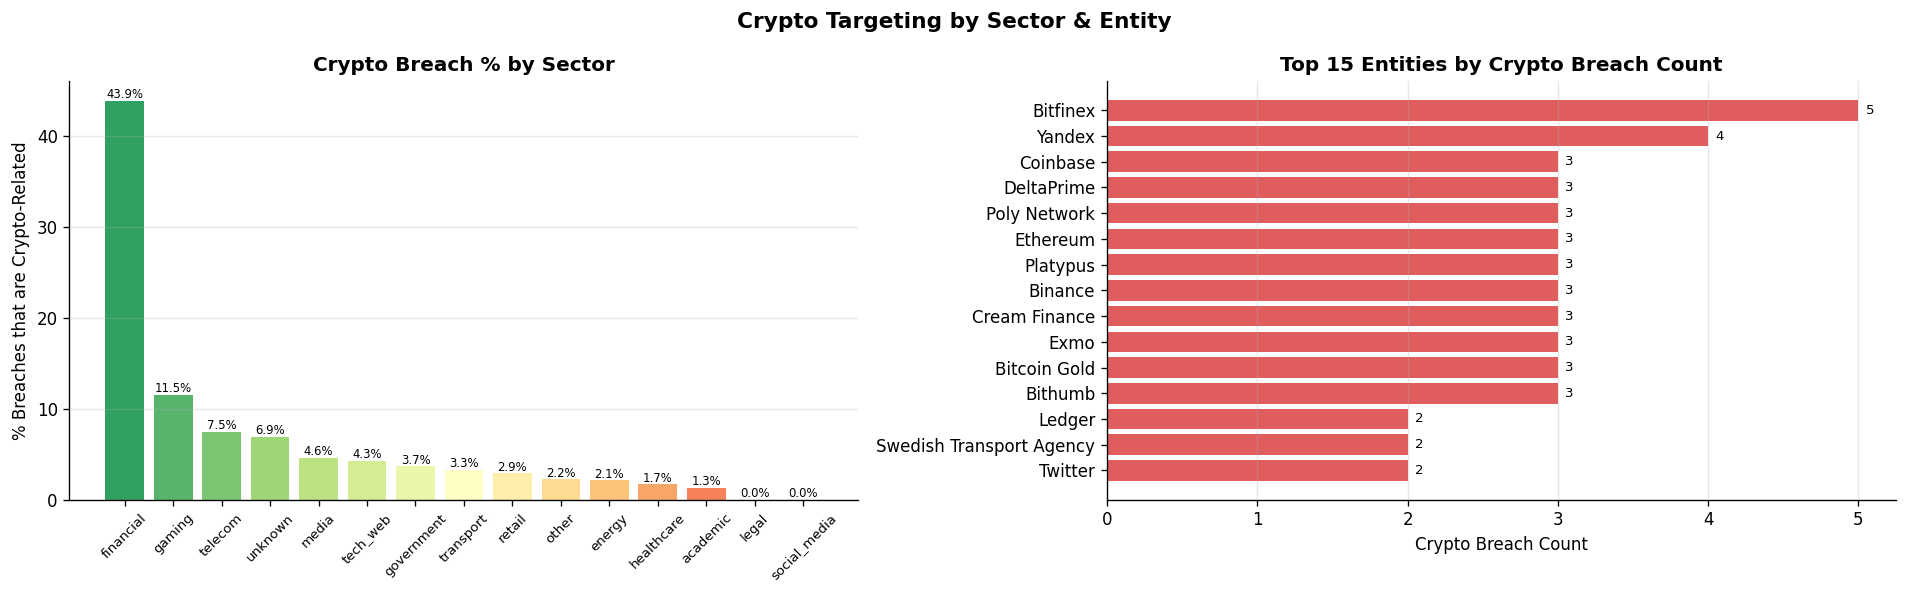

In [118]:
# ── 2F: Crypto fraction by sector & top entities ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Crypto Targeting by Sector & Entity', fontsize=13, fontweight='bold')

sec_total  = df.groupby('sector').size()
sec_crypto = (df[df['is_crypto']].groupby('sector').size()
              .reindex(sec_total.index, fill_value=0))
sec_frac   = (sec_crypto / sec_total * 100).sort_values(ascending=False)
bar_cols   = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(sec_frac)))
bars = axes[0].bar(sec_frac.index, sec_frac.values, color=bar_cols, alpha=0.9)
axes[0].set_title('Crypto Breach % by Sector', fontweight='bold')
axes[0].set_ylabel('% Breaches that are Crypto-Related')
axes[0].tick_params(axis='x', rotation=45, labelsize=8)
axes[0].grid(axis='y', alpha=0.3)
for bar, val in zip(bars, sec_frac.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.3, f'{val:.1f}%', ha='center', fontsize=7)

top_ents = df[df['is_crypto']]['entity'].value_counts().head(15)
axes[1].barh(top_ents.index[::-1], top_ents.values[::-1],
             color='#d62728', alpha=0.75)
axes[1].set_title('Top 15 Entities by Crypto Breach Count', fontweight='bold')
axes[1].set_xlabel('Crypto Breach Count')
axes[1].grid(axis='x', alpha=0.3)
for i, v in enumerate(top_ents.values[::-1]):
    axes[1].text(v + 0.05, i, str(v), va='center', fontsize=8)

plt.tight_layout(); plt.show()


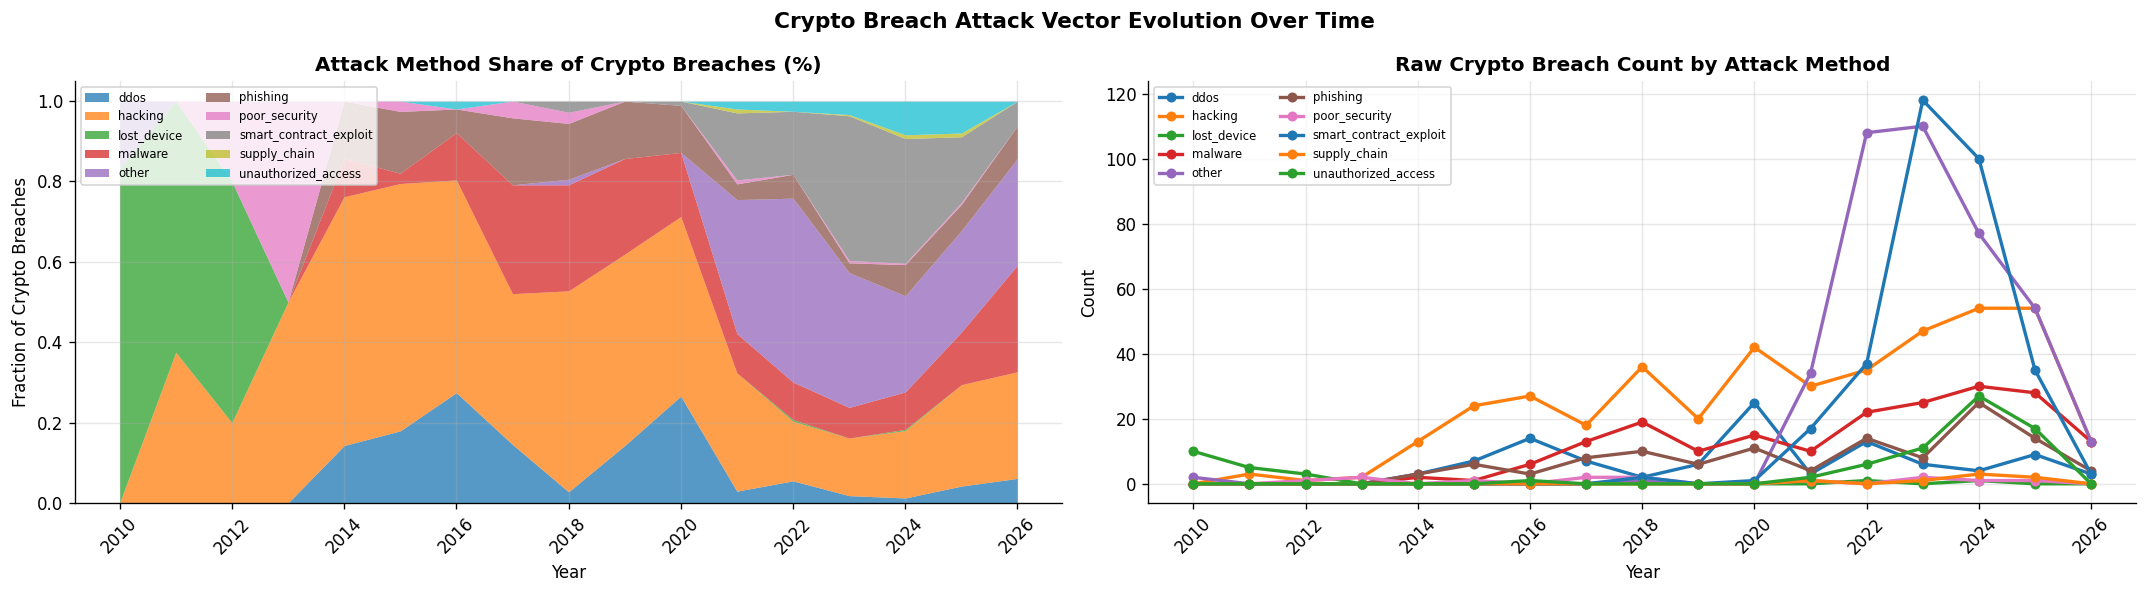

Shows which attack vectors drove crypto breach growth over time


In [119]:
# ── 2G: Crypto attack vector evolution over time ───────────────────────
crypto_df = df[df['is_crypto']]
method_yr = (crypto_df
             .groupby(['year', 'method_category'])
             .size()
             .unstack(fill_value=0))

# Keep only methods with ≥5 total crypto incidents for clarity
method_yr = method_yr.loc[:, method_yr.sum() >= 5]

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
fig.suptitle('Crypto Breach Attack Vector Evolution Over Time',
             fontsize=13, fontweight='bold')

# Left: stacked area — share of each method per year
method_yr_pct = method_yr.div(method_yr.sum(axis=1).replace(0, 1), axis=0)
method_yr_pct.plot.area(ax=axes[0], colormap='tab10', alpha=0.75, linewidth=0)
axes[0].set_title('Attack Method Share of Crypto Breaches (%)', fontweight='bold')
axes[0].set_xlabel('Year'); axes[0].set_ylabel('Fraction of Crypto Breaches')
axes[0].legend(fontsize=7, ncol=2, loc='upper left')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(alpha=0.3)

# Right: raw counts per method — shows absolute rise of each vector
for i, col in enumerate(method_yr.columns):
    axes[1].plot(method_yr.index, method_yr[col], 'o-', linewidth=2,
                 markersize=5, color=PALETTE[i % len(PALETTE)], label=col)
axes[1].set_title('Raw Crypto Breach Count by Attack Method', fontweight='bold')
axes[1].set_xlabel('Year'); axes[1].set_ylabel('Count')
axes[1].legend(fontsize=7, ncol=2); axes[1].grid(alpha=0.3)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout(); plt.show()
print('Shows which attack vectors drove crypto breach growth over time')


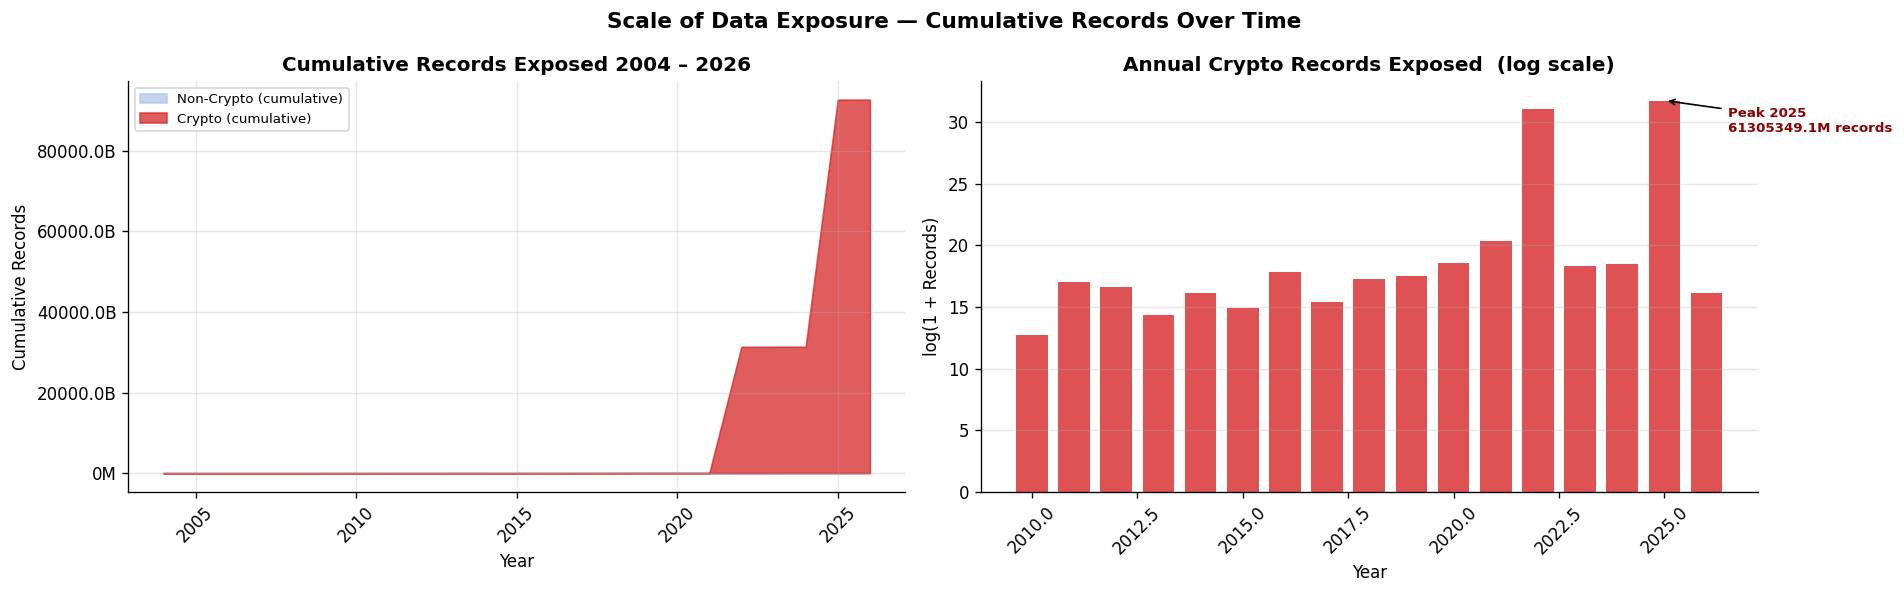

In [120]:
# ── 2H: Cumulative data exposure over time ────────────────────────────
yr_rec = (df.groupby(['year', 'is_crypto'])['records_affected']
          .sum().unstack(fill_value=0))
yr_rec.columns = ['Non-Crypto', 'Crypto']
yr_rec_cum = yr_rec.cumsum()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Scale of Data Exposure — Cumulative Records Over Time',
             fontsize=13, fontweight='bold')

# Left: stacked cumulative area
ax = axes[0]
ax.fill_between(yr_rec_cum.index, 0, yr_rec_cum['Non-Crypto'],
                color='#aec7e8', alpha=0.75, label='Non-Crypto (cumulative)')
ax.fill_between(yr_rec_cum.index,
                yr_rec_cum['Non-Crypto'],
                yr_rec_cum['Non-Crypto'] + yr_rec_cum['Crypto'],
                color='#d62728', alpha=0.75, label='Crypto (cumulative)')
ax.set_title('Cumulative Records Exposed 2004 – 2026', fontweight='bold')
ax.set_xlabel('Year'); ax.set_ylabel('Cumulative Records')
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x/1e9:.1f}B' if x >= 1e9 else f'{x/1e6:.0f}M'))
ax.legend(fontsize=8); ax.grid(alpha=0.3)
ax.tick_params(axis='x', rotation=45)

# Right: annual crypto records on log scale, peak annotated
yr_crypto_rec = df[df['is_crypto']].groupby('year')['records_affected'].sum()
axes[1].bar(yr_crypto_rec.index, np.log1p(yr_crypto_rec.values),
            color='#d62728', alpha=0.8, width=0.75)
axes[1].set_title('Annual Crypto Records Exposed  (log scale)', fontweight='bold')
axes[1].set_xlabel('Year'); axes[1].set_ylabel('log(1 + Records)')
axes[1].grid(axis='y', alpha=0.3)
axes[1].tick_params(axis='x', rotation=45)
if len(yr_crypto_rec) > 0:
    pk_yr  = yr_crypto_rec.idxmax()
    pk_val = yr_crypto_rec.max()
    axes[1].annotate(
        f'Peak {pk_yr}\n{pk_val/1e6:.1f}M records',
        xy=(pk_yr, np.log1p(pk_val)),
        xytext=(pk_yr + 1.5, np.log1p(pk_val) * 0.92),
        arrowprops=dict(arrowstyle='->', color='black'),
        fontsize=8, color='darkred', fontweight='bold')

plt.tight_layout(); plt.show()


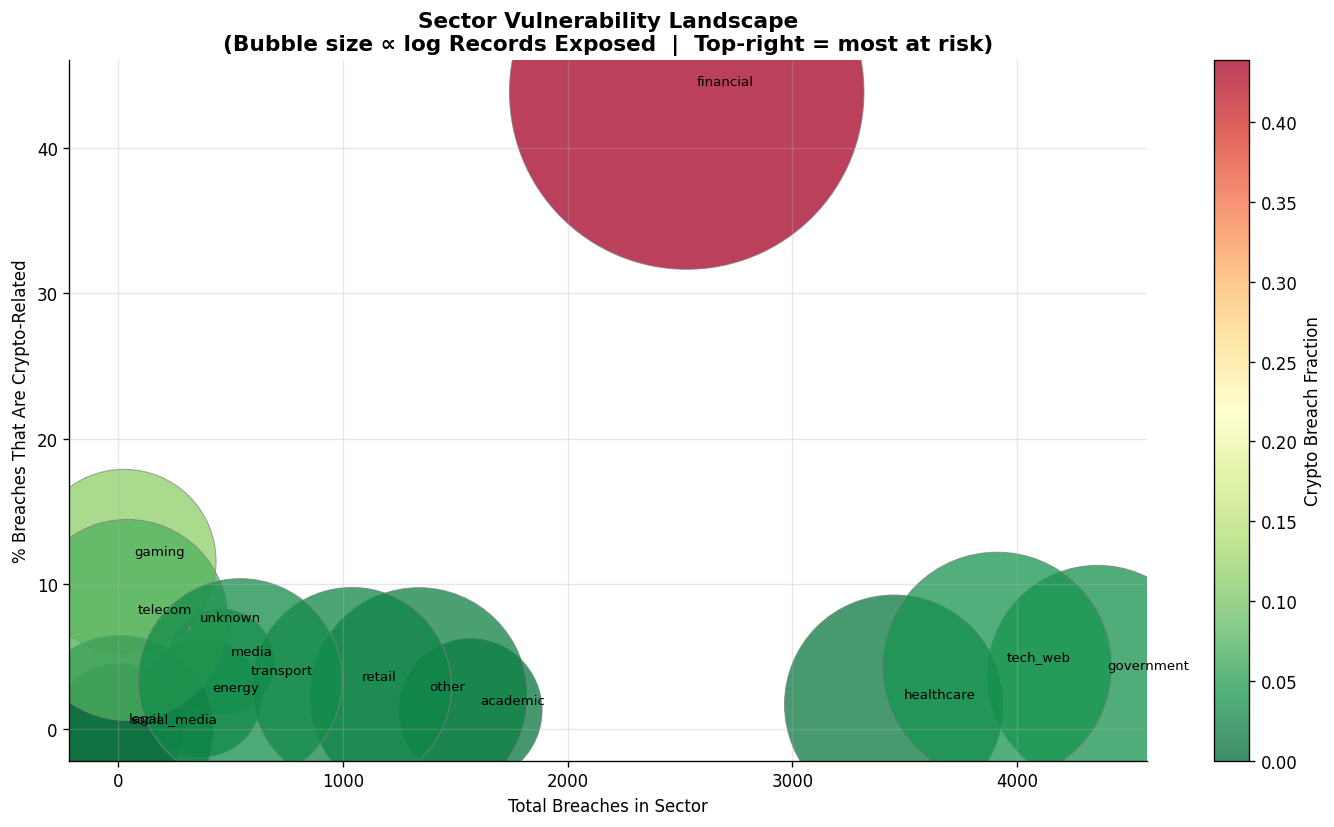

In [121]:
# ── 2I: Sector vulnerability bubble chart ─────────────────────────────
# x = total breaches, y = crypto fraction, bubble size ∝ log(records exposed)
sec_stats = df.groupby('sector').agg(
    total=('is_crypto', 'count'),
    crypto_count=('is_crypto', 'sum'),
    records=('records_affected', 'sum')
).reset_index()
sec_stats['crypto_frac'] = sec_stats['crypto_count'] / sec_stats['total']
sec_stats['log_records'] = np.log1p(sec_stats['records'].fillna(0))

fig, ax = plt.subplots(figsize=(12, 7))

sizes   = (sec_stats['log_records'] + 1) ** 2.8 * 2.5
scatter = ax.scatter(
    sec_stats['total'], sec_stats['crypto_frac'] * 100,
    s=sizes, c=sec_stats['crypto_frac'],
    cmap='RdYlGn_r', alpha=0.75,
    edgecolors='grey', linewidths=0.6,
    vmin=0, vmax=sec_stats['crypto_frac'].max()
)
for _, row in sec_stats.iterrows():
    ax.annotate(row['sector'],
                xy=(row['total'], row['crypto_frac'] * 100),
                xytext=(6, 4), textcoords='offset points',
                fontsize=8)

plt.colorbar(scatter, ax=ax, label='Crypto Breach Fraction')
ax.set_xlabel('Total Breaches in Sector', fontsize=10)
ax.set_ylabel('% Breaches That Are Crypto-Related', fontsize=10)
ax.set_title('Sector Vulnerability Landscape\n'
             '(Bubble size ∝ log Records Exposed  |  Top-right = most at risk)',
             fontsize=13, fontweight='bold')
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


---
## 🔧 Stage 3 — Feature Engineering

Transform the raw incident table into a **yearly feature matrix** suitable for ML:

- Annual breach counts, crypto fraction, log-records
- **Sector one-hot fractions** (7 sectors)
- **Method one-hot fractions** (10 attack types)
- **Lag features** (1-year, 2-year) for key indicators
- **Rolling mean/std** windows (2, 3 years)
- **Interaction terms**: hacking × financial, records × crypto count
- **Year-over-year growth** rates

Label: `1` if ≥1 crypto breach occurred that year.


In [122]:
from feature_engineering import build_feature_matrix

X, y, feature_names, scaler, yearly_df = build_feature_matrix(
    df, target_mode='crypto_binary', scale=True
)

print(f'Feature matrix shape: {X.shape}')
print(f'Years covered:        {X.index.min()} – {X.index.max()}')
print(f'Positive class rate:  {y.mean():.2%}  ({y.sum()} / {len(y)} years had crypto breaches)')
print(f'\nFirst 5 feature names: {feature_names[:5]}')
print(f'Last 5 feature names:  {feature_names[-5:]}')


Feature matrix shape: (23, 37)
Years covered:        2004 – 2026
Positive class rate:  47.83%  (11 / 23 years had crypto breaches)

First 5 feature names: ['log_records_total', 'mean_records', 'unique_entities', 'unique_methods', 'source_diversity']
Last 5 feature names:  ['crypto_breach_count_delta', 'crypto_breach_count_rising', 'breach_trend_slope', 'crypto_trend_slope', 'crypto_momentum']


In [123]:
# Show the yearly aggregated DataFrame
display(HTML('<b>Yearly Aggregated Feature Table</b>'))
display(
    yearly_df[['total_breaches','crypto_breach_count','crypto_fraction',
               'log_records_total','unique_entities','unique_methods']]
    .style
    .background_gradient(subset=['crypto_breach_count'], cmap='Reds')
    .background_gradient(subset=['total_breaches'], cmap='Blues')
    .format({'crypto_fraction': '{:.1%}', 'log_records_total': '{:.2f}'})
)


,total_breaches,crypto_breach_count,crypto_fraction,log_records_total,unique_entities,unique_methods
year,,,,,,
2004,4,0.000000,0.0%,19.03,3,3
2005,8,0.000000,0.0%,18.28,8,3
2006,10,0.000000,0.0%,18.56,10,5
2007,15,0.000000,0.0%,18.89,15,3
2008,39,0.000000,0.0%,18.65,39,6
2009,68,0.000000,0.0%,19.66,67,5
2010,223,12.000000,5.4%,17.18,219,6
2011,257,8.000000,3.1%,19.76,250,6
2012,203,5.000000,2.5%,20.89,199,6


In [124]:
# Show scaled feature matrix
display(HTML('<b>Scaled Feature Matrix (first 5 columns, all years)</b>'))
display(
    X.iloc[:, :8]
    .style
    .background_gradient(cmap='RdBu_r', axis=0)
    .format('{:.3f}')
)


,log_records_total,mean_records,unique_entities,unique_methods,source_diversity,large_breach_count,sector_financial,sector_government
year,,,,,,,,
2004,-0.627,-0.306,-0.993,-1.711,-1.153,-1.490,-0.804,-1.520
2005,-0.838,-0.307,-0.987,-1.711,-1.982,-1.263,4.143,-1.520
2006,-0.760,-0.307,-0.985,-0.962,-1.153,-1.111,0.892,0.128
2007,-0.667,-0.307,-0.979,-1.711,-1.982,-0.883,0.703,1.226
2008,-0.735,-0.307,-0.951,-0.587,0.505,-0.049,0.355,0.592
2009,-0.452,-0.307,-0.919,-0.962,-0.324,-0.732,-0.638,-0.672
2010,-1.149,-0.307,-0.741,-0.587,0.505,-0.883,-0.678,-1.298
2011,-0.423,-0.307,-0.705,-0.587,-0.324,0.481,-0.738,-1.135
2012,-0.103,-0.307,-0.765,-0.587,0.505,0.481,-0.582,-1.317


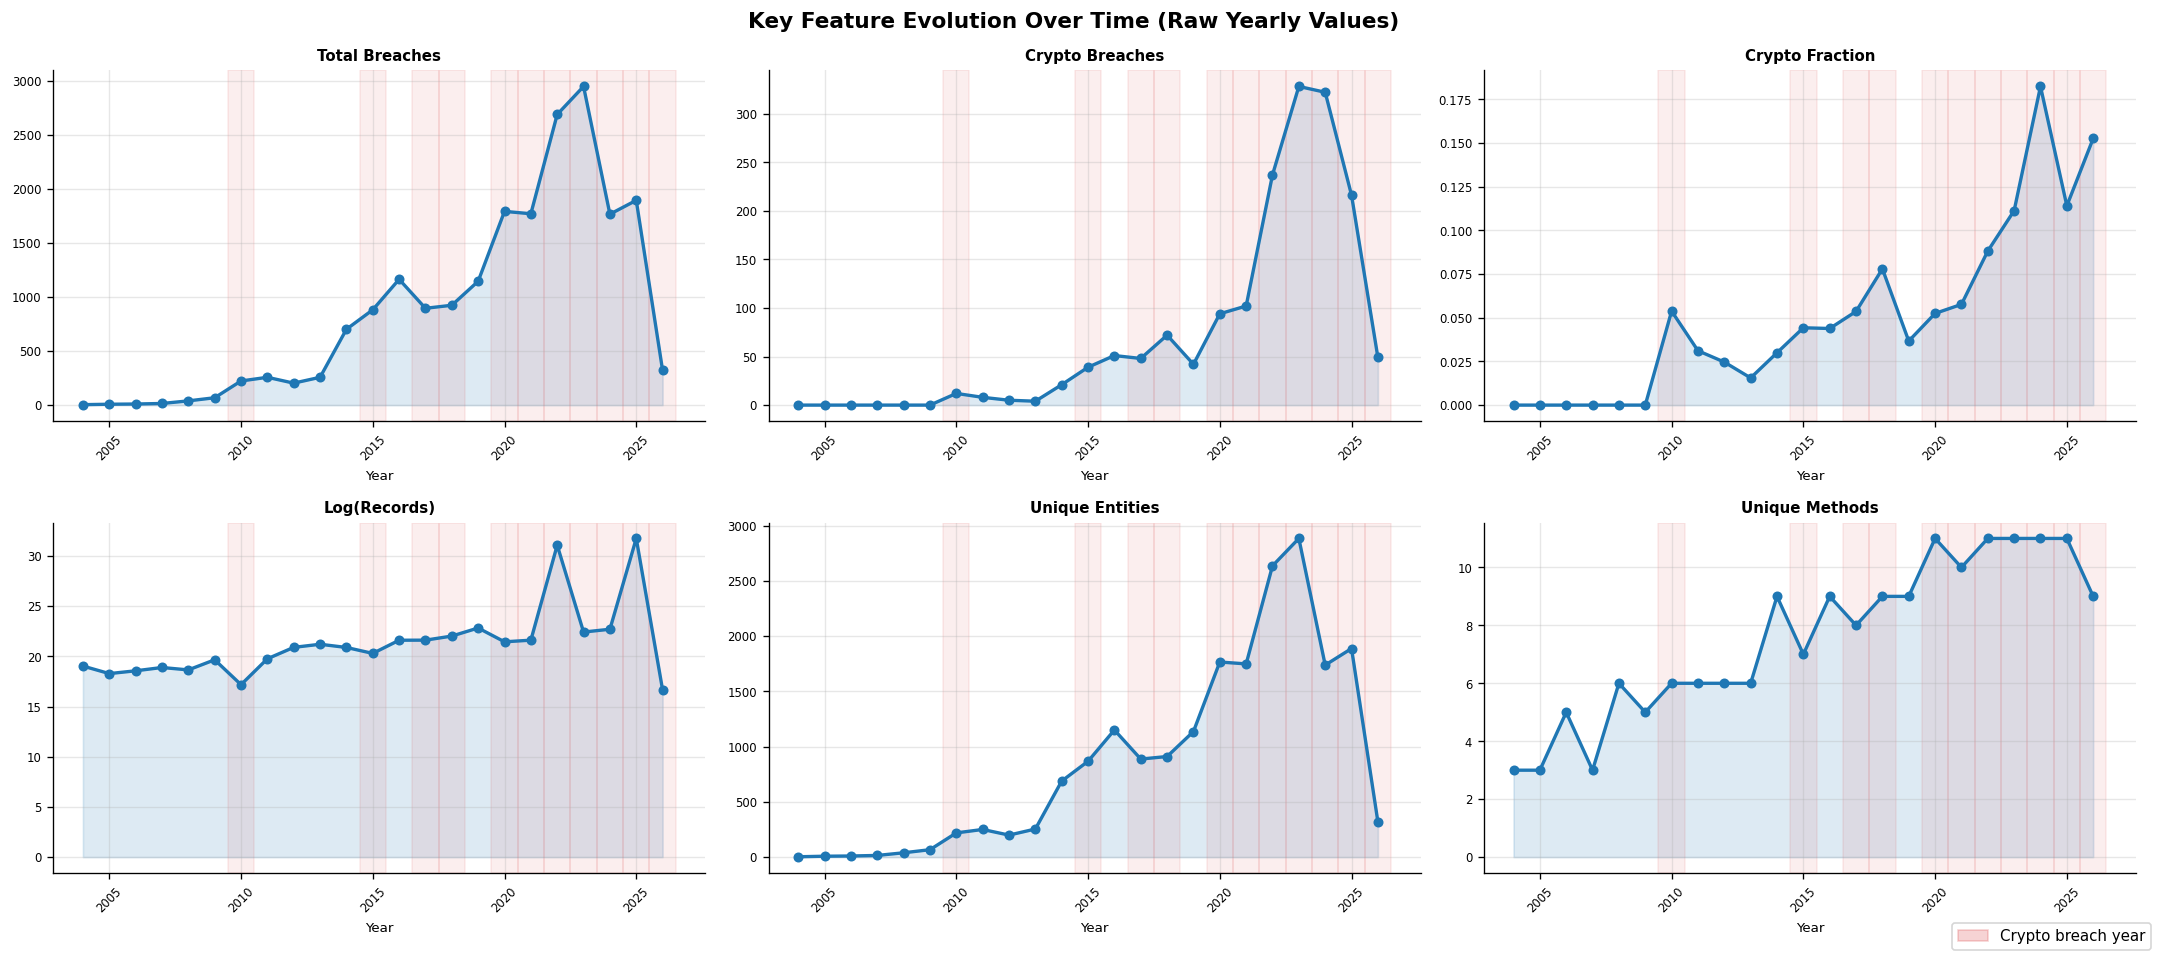

In [125]:
# ── 3A: Key feature evolution over time (raw yearly values) ────────────
from matplotlib.patches import Patch

key_features = ['total_breaches', 'crypto_breach_count', 'crypto_fraction',
                'log_records_total', 'unique_entities', 'unique_methods']
key_labels   = ['Total Breaches', 'Crypto Breaches', 'Crypto Fraction',
                'Log(Records)', 'Unique Entities', 'Unique Methods']

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
fig.suptitle('Key Feature Evolution Over Time (Raw Yearly Values)',
             fontsize=13, fontweight='bold')

for ax, feat, label in zip(axes.flatten(), key_features, key_labels):
    if feat not in yearly_df.columns:
        ax.set_visible(False)
        continue
    vals = yearly_df[feat]
    ax.plot(vals.index, vals.values, 'o-', linewidth=2, markersize=5, color='#1f77b4')
    ax.fill_between(vals.index, vals.values, alpha=0.15, color='#1f77b4')
    for yr in yearly_df.index[y == 1]:
        ax.axvspan(yr - 0.5, yr + 0.5, color='#d62728', alpha=0.08)
    ax.set_title(label, fontweight='bold', fontsize=9)
    ax.set_xlabel('Year', fontsize=8)
    ax.grid(alpha=0.3)
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.tick_params(axis='y', labelsize=7)

fig.legend(
    handles=[Patch(color='#d62728', alpha=0.2, label='Crypto breach year')],
    loc='lower right', fontsize=9
)
plt.tight_layout(); plt.show()


---
## 🔍 Stage 4 — Feature Analysis

Examine feature distributions, correlations, and predictive value
before fitting any model.


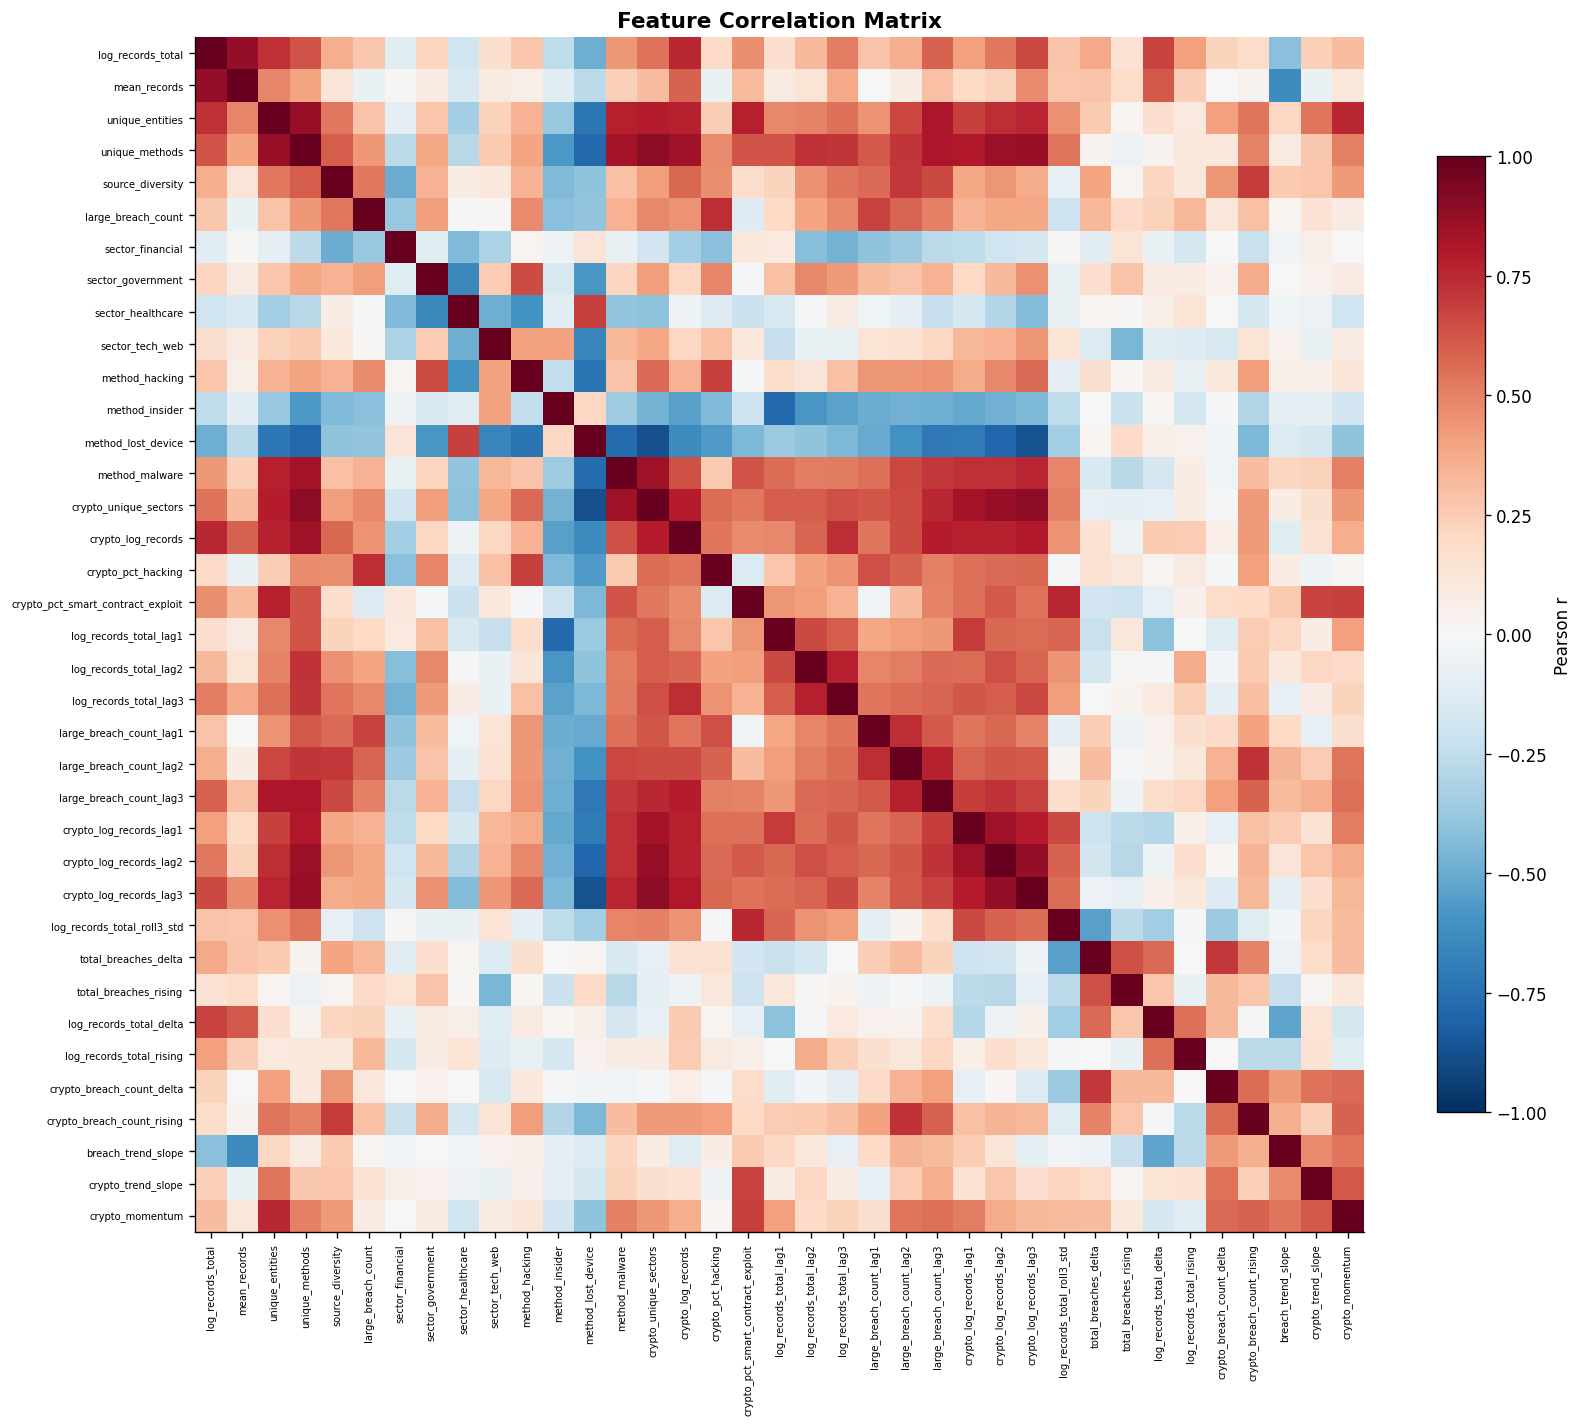

In [126]:
# ── 4A: Feature correlation heatmap ───────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 12))
corr = X.corr()
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90, fontsize=6)
ax.set_yticklabels(corr.columns, fontsize=6)
plt.colorbar(im, ax=ax, shrink=0.8, label='Pearson r')
ax.set_title('Feature Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


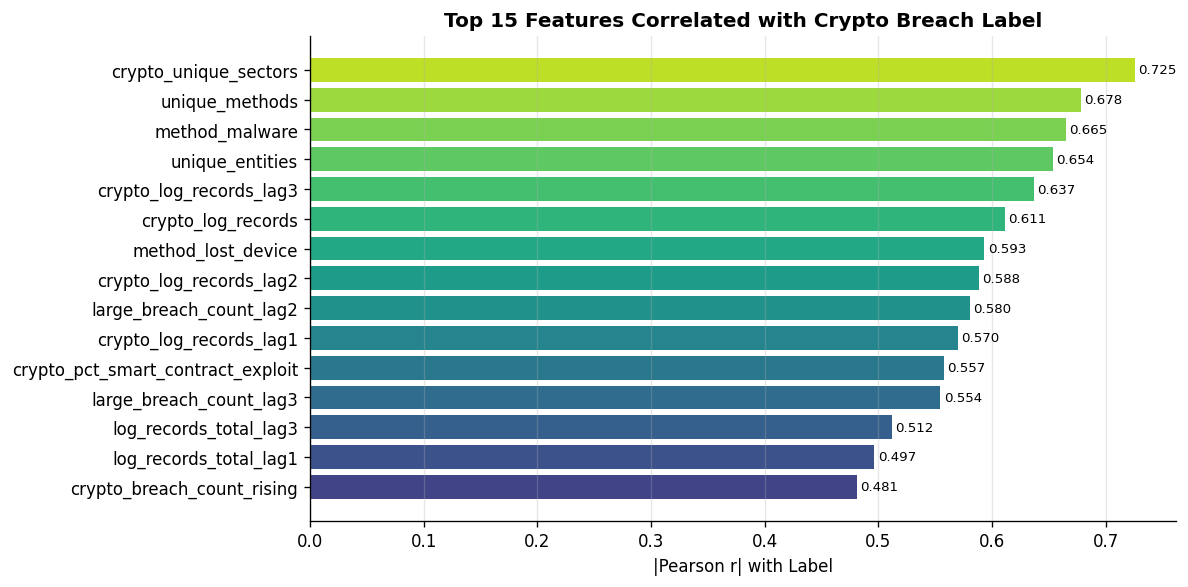

In [127]:
# ── 4B: Feature-label correlation (Pearson r with y) ──────────────────
corr_y = X.corrwith(y.astype(float)).abs().sort_values(ascending=False)
top15  = corr_y.head(15)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(top15.index[::-1], top15.values[::-1],
               color=plt.cm.viridis(np.linspace(0.2, 0.9, 15)))
ax.set_xlabel('|Pearson r| with Label')
ax.set_title('Top 15 Features Correlated with Crypto Breach Label',
             fontweight='bold')
ax.grid(axis='x', alpha=0.3)
for bar, val in zip(bars, top15.values[::-1]):
    ax.text(bar.get_width()+0.003, bar.get_y()+bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=8)
plt.tight_layout(); plt.show()


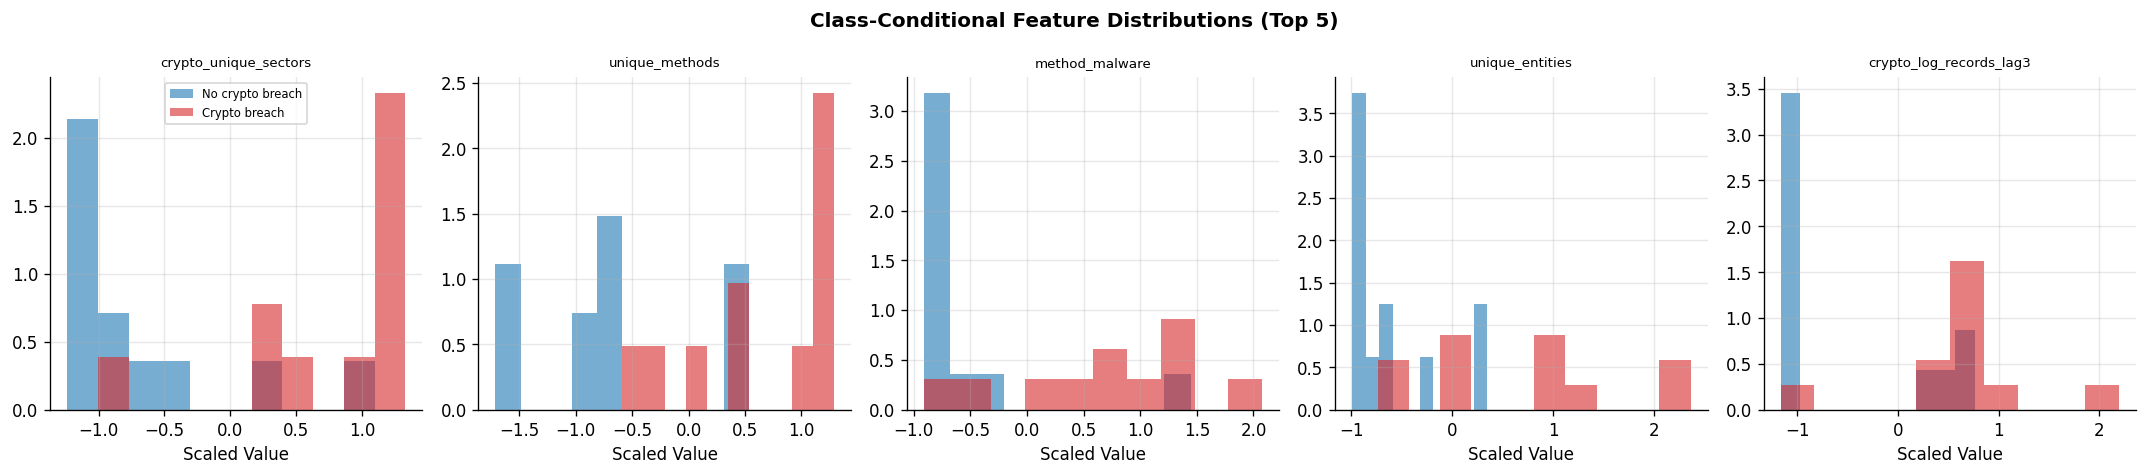

In [128]:
# ── 4C: Class-conditional feature distributions ────────────────────────
top5_feats = corr_y.head(5).index.tolist()
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
fig.suptitle('Class-Conditional Feature Distributions (Top 5)', fontweight='bold')

X_with_y = X.copy(); X_with_y['label'] = y
for ax, feat in zip(axes, top5_feats):
    for cls, colour, label in [(0,'#1f77b4','No crypto breach'),
                                (1,'#d62728','Crypto breach')]:
        vals = X_with_y[X_with_y['label']==cls][feat].dropna()
        ax.hist(vals, bins=10, alpha=0.6, color=colour, label=label, density=True)
    ax.set_title(feat[:25], fontsize=8)
    ax.set_xlabel('Scaled Value'); ax.grid(alpha=0.3)
    if ax == axes[0]:
        ax.legend(fontsize=7)

plt.tight_layout(); plt.show()


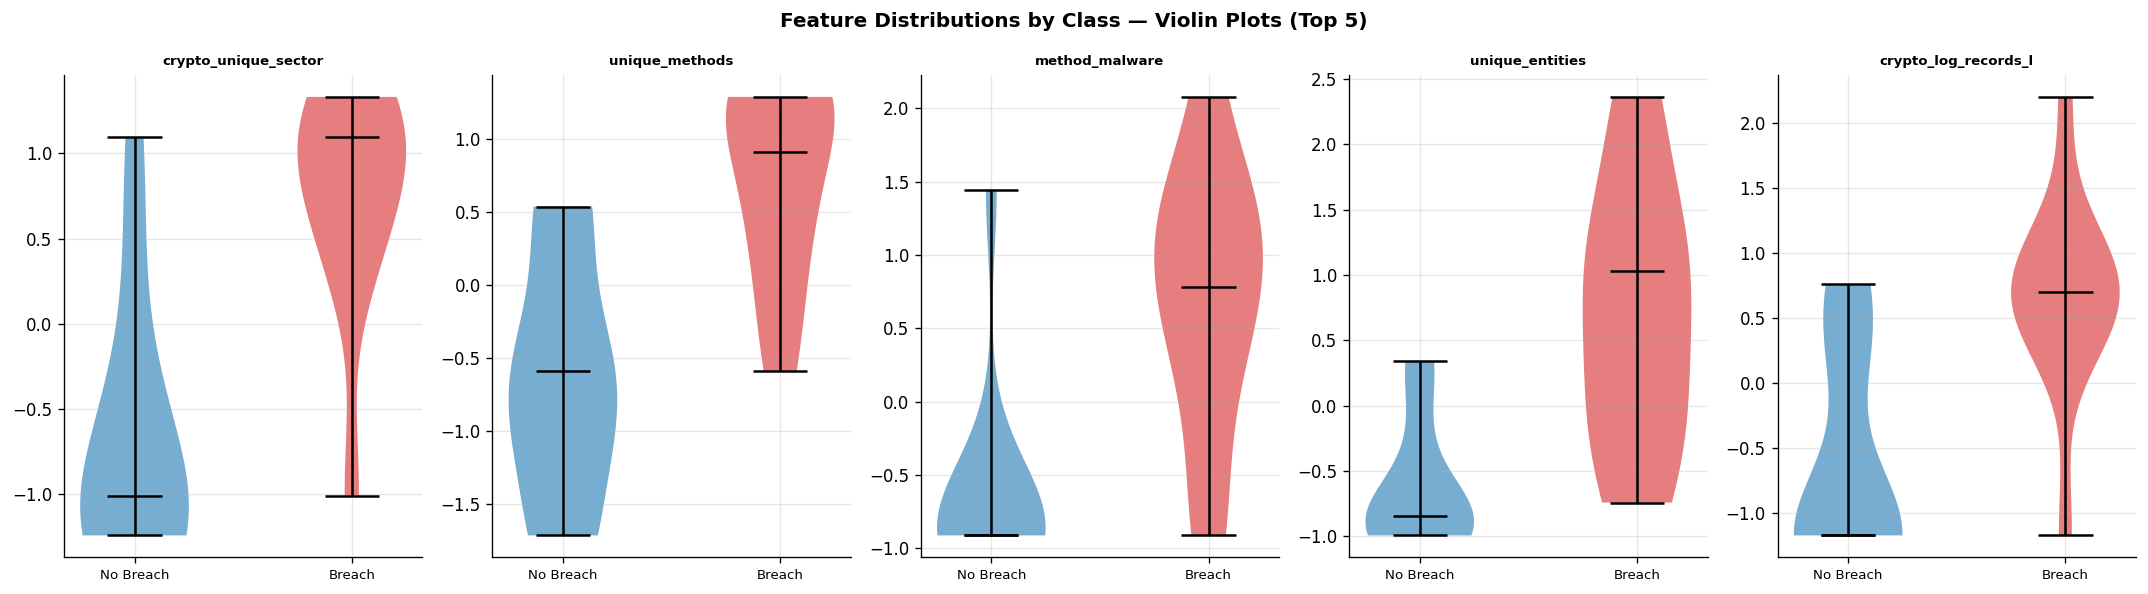

In [129]:
# ── 4D: Violin plots — top 5 features by class ─────────────────────────
top5_feats = corr_y.head(5).index.tolist()
fig, axes = plt.subplots(1, 5, figsize=(18, 5))
fig.suptitle('Feature Distributions by Class — Violin Plots (Top 5)', fontweight='bold')

X_vln = X.copy()
X_vln['label'] = y

for ax, feat in zip(axes, top5_feats):
    data_0 = X_vln[X_vln['label'] == 0][feat].dropna().values
    data_1 = X_vln[X_vln['label'] == 1][feat].dropna().values
    parts = ax.violinplot([data_0, data_1], positions=[0, 1],
                          showmedians=True, showextrema=True)
    parts['bodies'][0].set_facecolor('#1f77b4')
    parts['bodies'][0].set_alpha(0.6)
    parts['bodies'][1].set_facecolor('#d62728')
    parts['bodies'][1].set_alpha(0.6)
    for pc_key in ('cmedians', 'cmins', 'cmaxes', 'cbars'):
        if pc_key in parts:
            parts[pc_key].set_color('black')
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['No Breach', 'Breach'], fontsize=8)
    ax.set_title(feat[:20], fontsize=8, fontweight='bold')
    ax.grid(alpha=0.3)

plt.tight_layout(); plt.show()


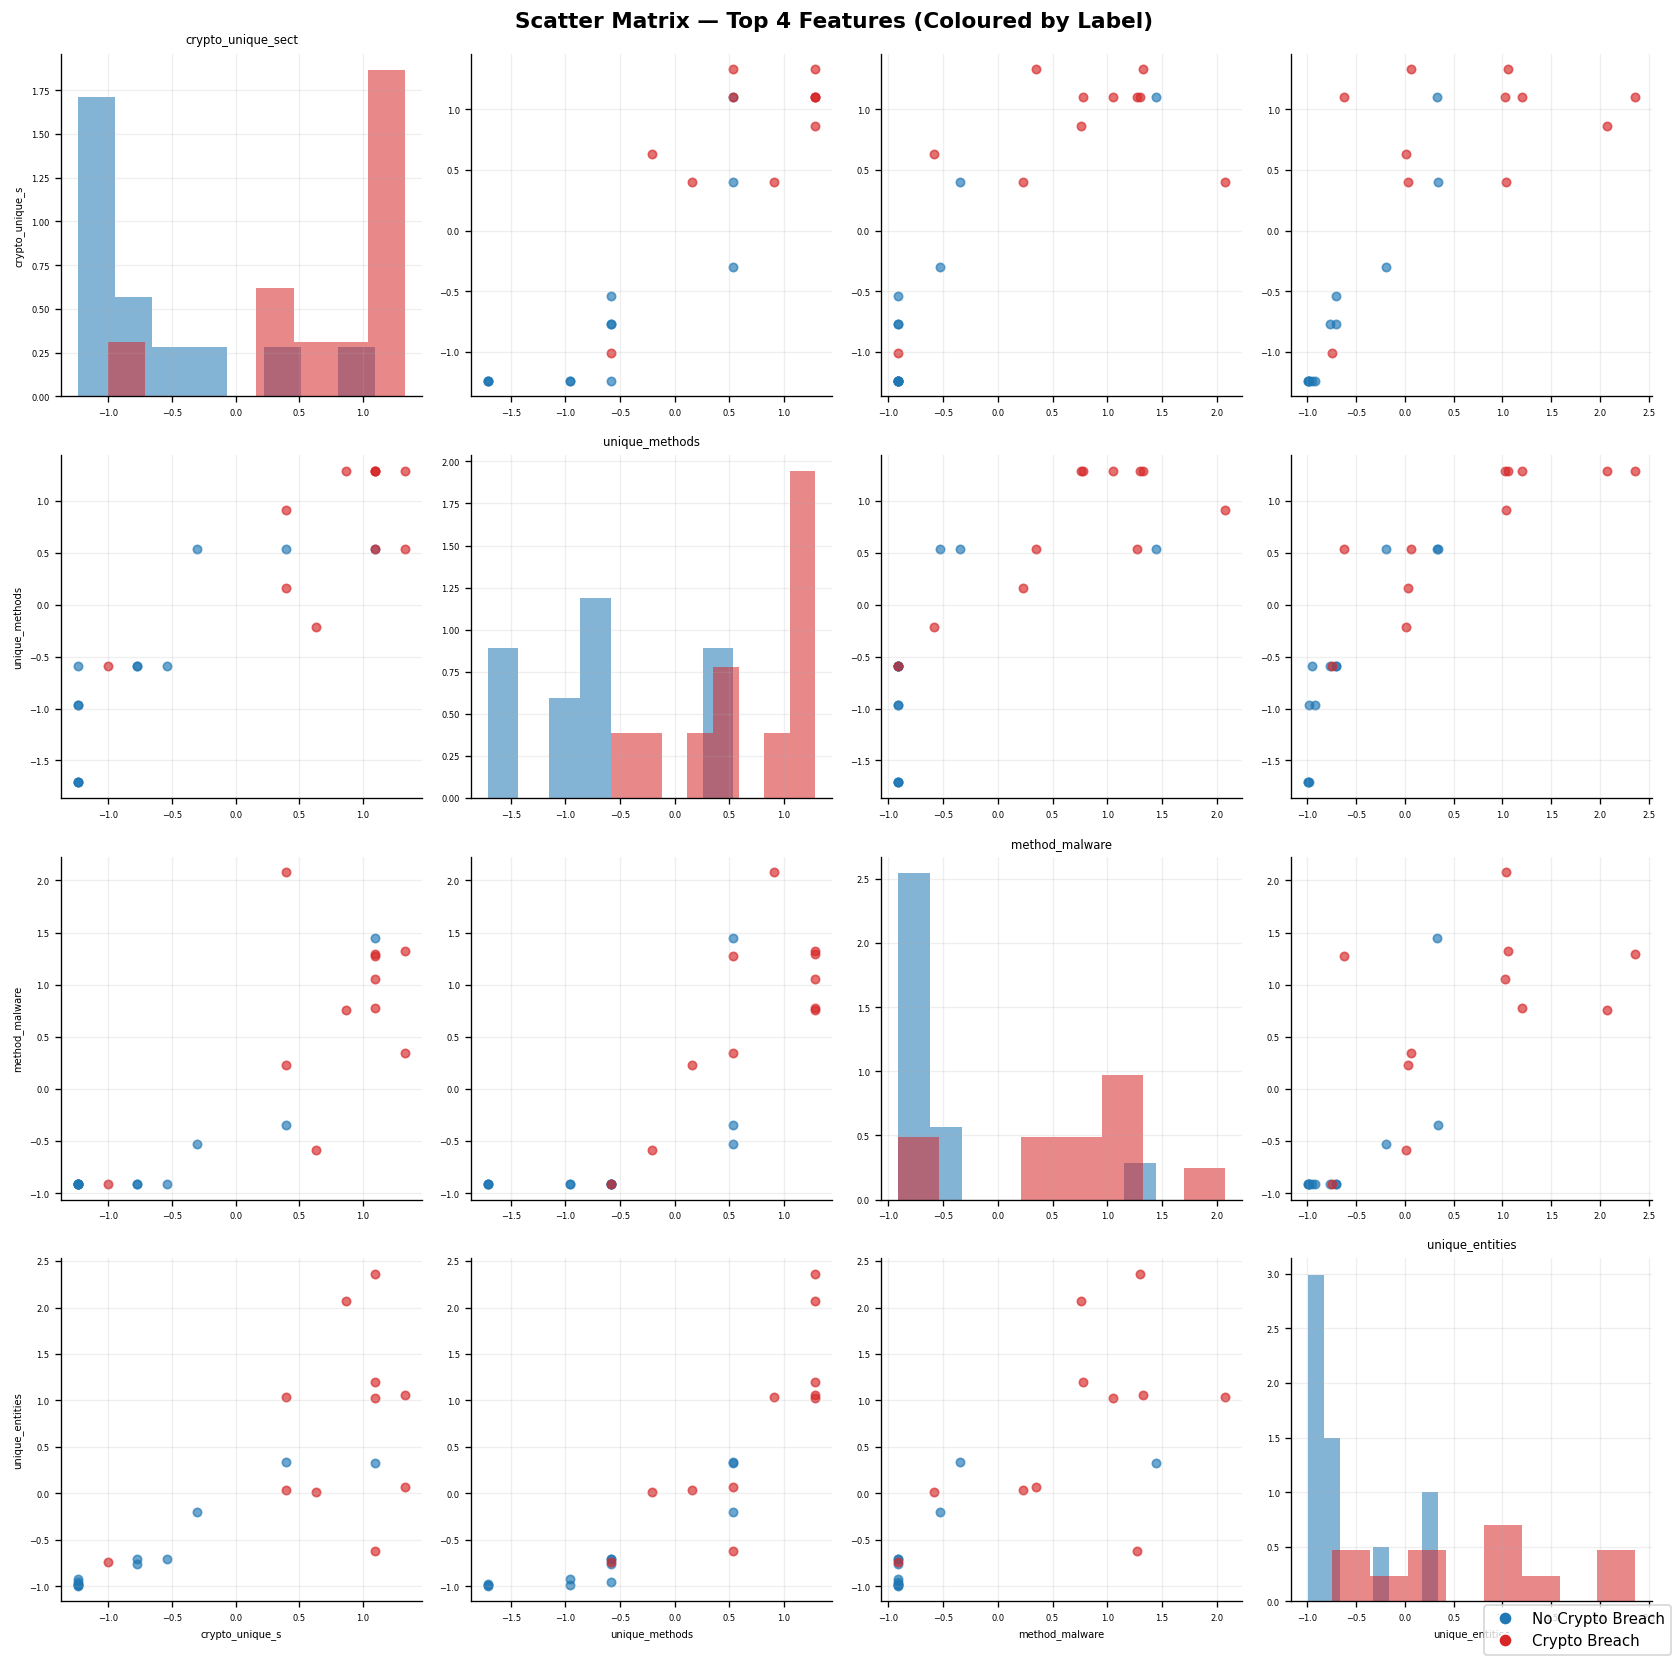

In [130]:
# ── 4E: Scatter matrix — top 4 features coloured by label ──────────────
top4 = corr_y.head(4).index.tolist()
X_top = X[top4].copy()
X_top['label'] = y

colours_map = {0: '#1f77b4', 1: '#d62728'}
label_name  = {0: 'No Crypto Breach', 1: 'Crypto Breach'}

fig, axes = plt.subplots(4, 4, figsize=(14, 14))
fig.suptitle('Scatter Matrix — Top 4 Features (Coloured by Label)',
             fontsize=13, fontweight='bold')

for i, feat_i in enumerate(top4):
    for j, feat_j in enumerate(top4):
        ax = axes[i][j]
        if i == j:
            for cls in [0, 1]:
                vals = X_top[X_top['label'] == cls][feat_i].dropna()
                ax.hist(vals, bins=8, alpha=0.55, color=colours_map[cls],
                        label=label_name[cls], density=True)
            ax.set_title(feat_i[:18], fontsize=7)
        else:
            for cls in [0, 1]:
                sub = X_top[X_top['label'] == cls]
                ax.scatter(sub[feat_j], sub[feat_i], s=25, alpha=0.65,
                           color=colours_map[cls], label=label_name[cls])
        if i == 3:
            ax.set_xlabel(feat_j[:15], fontsize=6)
        if j == 0:
            ax.set_ylabel(feat_i[:15], fontsize=6)
        ax.tick_params(labelsize=5)
        ax.grid(alpha=0.2)

from matplotlib.lines import Line2D
legend_handles = [Line2D([0], [0], marker='o', color='w',
                          markerfacecolor=c, markersize=8, label=l)
                  for c, l in zip(colours_map.values(), label_name.values())]
fig.legend(handles=legend_handles, loc='lower right', fontsize=9)
plt.tight_layout(); plt.show()


---
## 🤖 Stage 5 — Walk-Forward Model Training

We train **5 models** using **walk-forward (expanding-window) time-series CV**:

```
Fold 0: Train 2004–2008 → Test 2009
Fold 1: Train 2004–2009 → Test 2010
...
Fold N: Train 2004–(last-1) → Test last year
```

No fold ever uses future data to train. Calibration is applied via isotonic regression.


In [131]:
from models import WalkForwardValidator, build_models

wfv = WalkForwardValidator(
    train_window=None,   # expanding window
    min_train_size=5,
    calibrate=False,
)

# v2 models: LogisticRegression, RandomForest, ExtraTrees, GradientBoosting, SVM
models = build_models()
results = wfv.fit_predict(X, y, models=models)

print(f'Folds run: {len(results)}')
print(f'Models:    {list(models.keys())}')


Folds run: 80
Models:    ['LogisticRegression', 'RidgeClassifier', 'RandomForest', 'ExtraTrees', 'GradientBoosting']


In [132]:
# Per-fold predictions table
preds_df = wfv.consolidated_predictions()
display(HTML('<b>Walk-Forward Predictions (first 20 rows)</b>'))
display(
    preds_df.head(20)
    .style
    .background_gradient(subset=['y_prob'], cmap='RdYlGn_r')
    .map(lambda v: 'color: red; font-weight: bold' if v == 1 else '',
        subset=['y_true'])
    .format({'y_prob': '{:.3f}'})
)


,year,model,fold,y_true,y_prob,high_risk
0,2011,LogisticRegression,7,0,0.763,1
1,2011,RidgeClassifier,7,0,0.714,1
2,2011,RandomForest,7,0,0.360,0
3,2011,ExtraTrees,7,0,0.541,1
4,2011,GradientBoosting,7,0,0.030,0
5,2012,LogisticRegression,8,0,0.173,0
6,2012,RidgeClassifier,8,0,0.248,0
7,2012,RandomForest,8,0,0.344,0
8,2012,ExtraTrees,8,0,0.514,1
9,2012,GradientBoosting,8,0,0.023,0


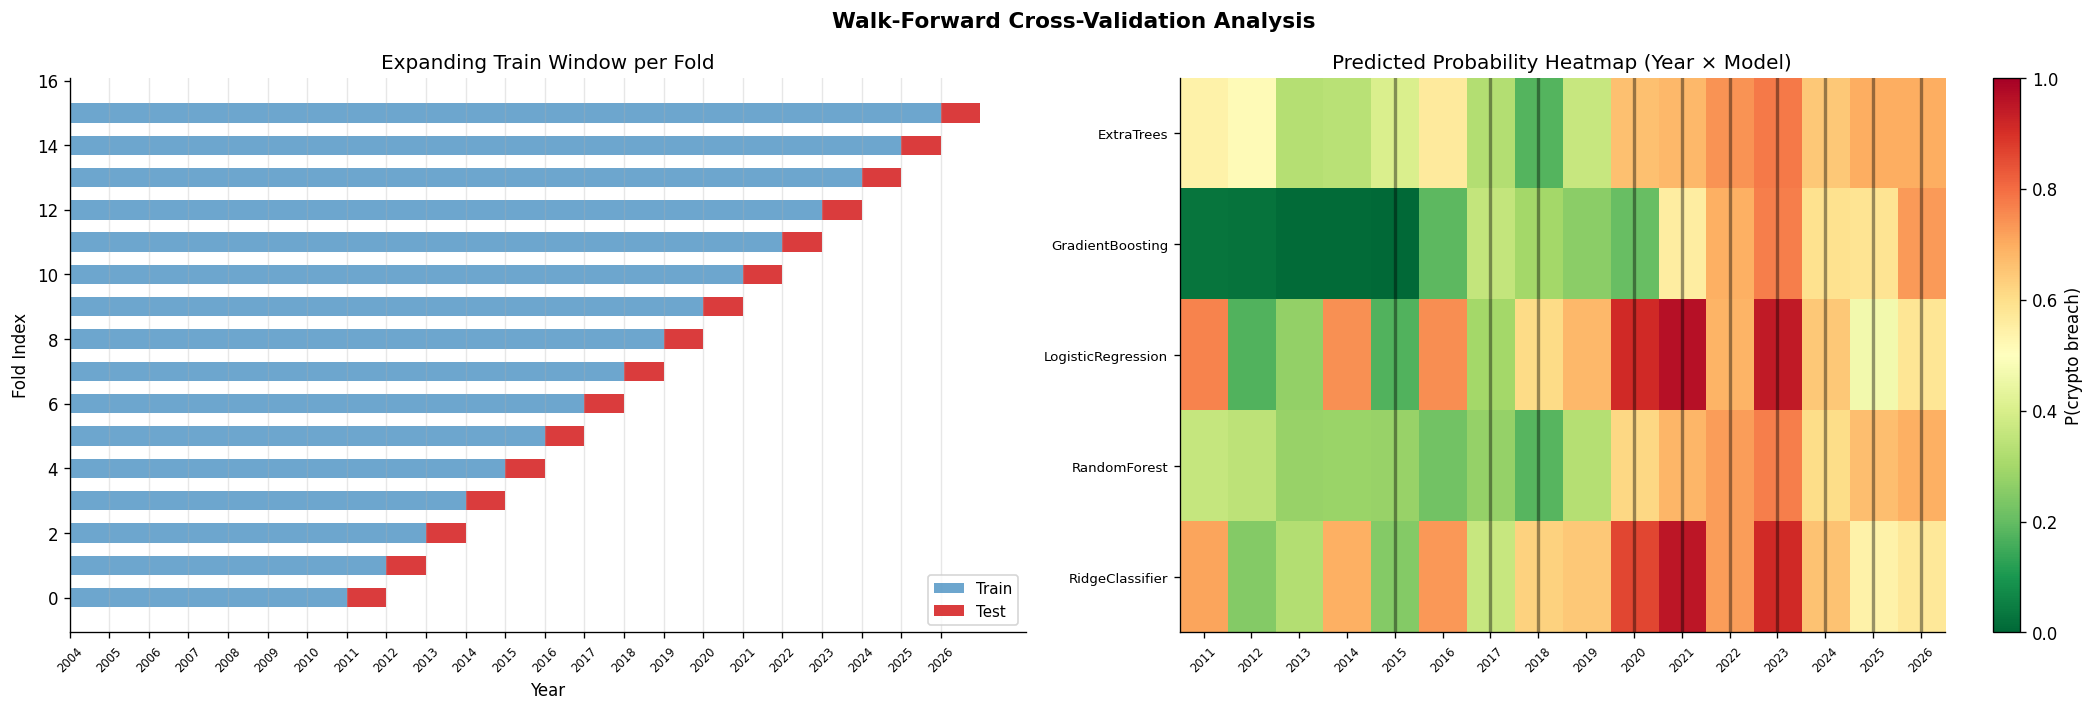

Vertical black lines = years with actual crypto breaches


In [133]:
# ── 5A: Walk-forward split visualisation & predicted prob heatmap ───────
all_years  = sorted(X.index.tolist())
test_years = sorted(preds_df['year'].unique())

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Walk-Forward Cross-Validation Analysis', fontsize=13, fontweight='bold')

# Left: expanding train window per fold
for fold_i, test_yr in enumerate(test_years):
    train_yrs = [yr for yr in all_years if yr < test_yr]
    if not train_yrs:
        continue
    axes[0].barh(fold_i, len(train_yrs), left=min(train_yrs),
                 height=0.6, color='#1f77b4', alpha=0.65,
                 label='Train' if fold_i == 0 else '')
    axes[0].barh(fold_i, 1, left=test_yr,
                 height=0.6, color='#d62728', alpha=0.9,
                 label='Test' if fold_i == 0 else '')

axes[0].set_xlabel('Year'); axes[0].set_ylabel('Fold Index')
axes[0].set_title('Expanding Train Window per Fold')
axes[0].legend(fontsize=9); axes[0].grid(axis='x', alpha=0.3)
axes[0].set_xticks(all_years)
axes[0].set_xticklabels(all_years, rotation=45, fontsize=7)

# Right: predicted probability heatmap (year × model)
pivot_prob = preds_df.pivot_table(index='year', columns='model', values='y_prob')
im = axes[1].imshow(pivot_prob.values.T, aspect='auto',
                    cmap='RdYlGn_r', vmin=0, vmax=1)
axes[1].set_yticks(range(len(pivot_prob.columns)))
axes[1].set_yticklabels(pivot_prob.columns, fontsize=8)
axes[1].set_xticks(range(len(pivot_prob.index)))
axes[1].set_xticklabels(pivot_prob.index, rotation=45, fontsize=7)
axes[1].set_title('Predicted Probability Heatmap (Year × Model)')
plt.colorbar(im, ax=axes[1], label='P(crypto breach)')

actual_breach_yrs = preds_df.groupby('year')['y_true'].max()
for xi, (yr, is_breach) in enumerate(actual_breach_yrs.items()):
    if is_breach:
        axes[1].axvline(xi, color='black', linewidth=2, alpha=0.4)

plt.tight_layout(); plt.show()
print('Vertical black lines = years with actual crypto breaches')


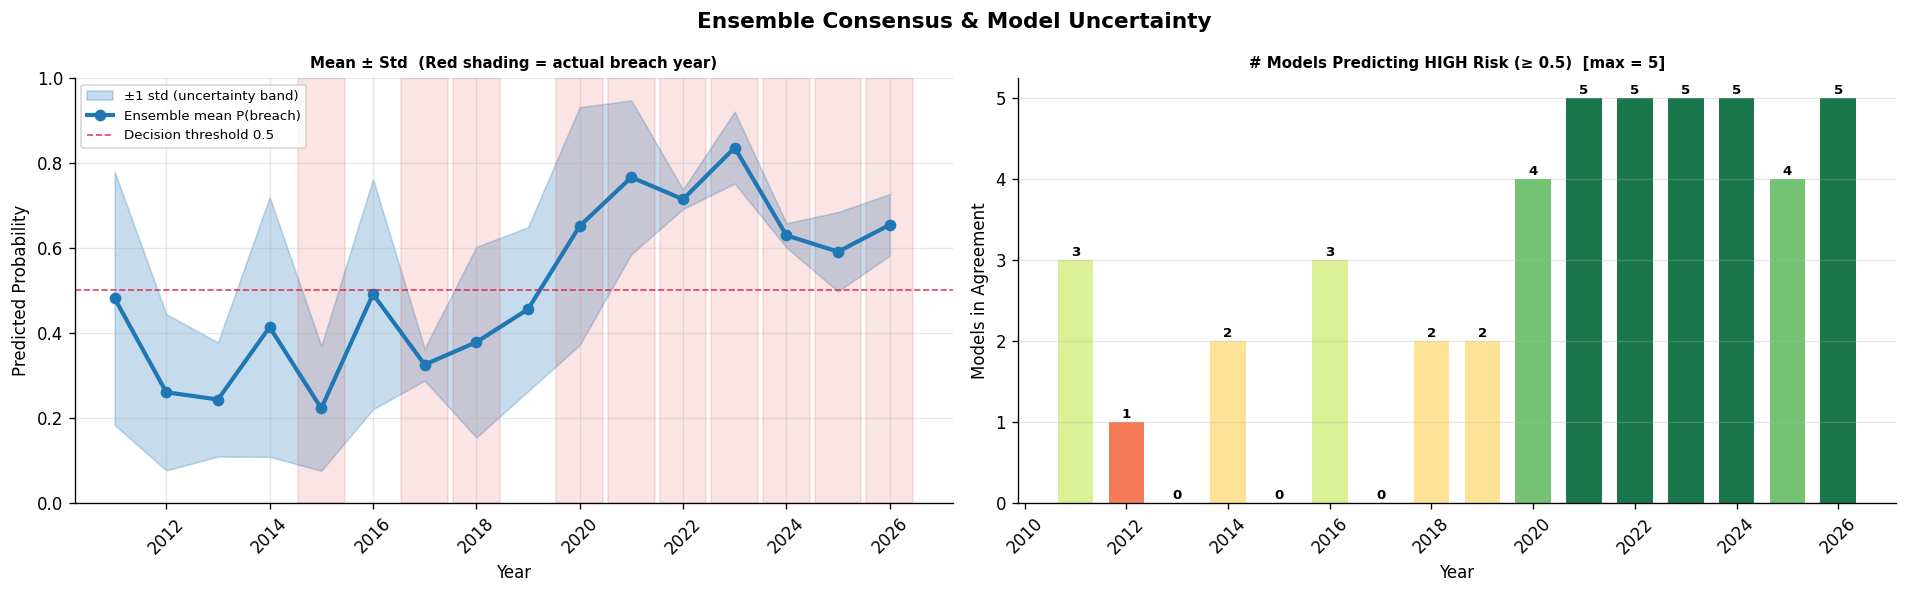

Green = all models agree on HIGH risk; Red = unanimous LOW or split opinion


In [134]:
# ── 5B: Ensemble consensus & uncertainty over time ────────────────────
pivot_prob = preds_df.pivot_table(index='year', columns='model', values='y_prob')
ens_mean   = pivot_prob.mean(axis=1)
ens_std    = pivot_prob.std(axis=1)
actual     = preds_df.groupby('year')['y_true'].max()
agree_high = (pivot_prob >= 0.5).sum(axis=1)   # how many models say HIGH

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Ensemble Consensus & Model Uncertainty', fontsize=13, fontweight='bold')

# Left: ensemble mean ± 1 std with actual breach years shaded
ax = axes[0]
ax.fill_between(ens_mean.index,
                (ens_mean - ens_std).clip(0, 1),
                (ens_mean + ens_std).clip(0, 1),
                alpha=0.25, color='#1f77b4', label='±1 std (uncertainty band)')
ax.plot(ens_mean.index, ens_mean.values, 'o-', linewidth=2.5,
        color='#1f77b4', label='Ensemble mean P(breach)')
for yr, breach in actual.items():
    if breach:
        ax.axvspan(yr - 0.45, yr + 0.45, color='#d62728', alpha=0.12)
ax.axhline(0.5, color='crimson', linestyle='--', linewidth=1, alpha=0.8,
           label='Decision threshold 0.5')
ax.set_title('Mean ± Std  (Red shading = actual breach year)',
             fontweight='bold', fontsize=9)
ax.set_xlabel('Year'); ax.set_ylabel('Predicted Probability')
ax.legend(fontsize=8); ax.grid(alpha=0.3); ax.set_ylim(0, 1)
ax.tick_params(axis='x', rotation=45)

# Right: model agreement bar — N models predicting breach
n_models = len(pivot_prob.columns)
agree_colours = plt.cm.RdYlGn(agree_high.values / n_models)
axes[1].bar(agree_high.index, agree_high.values, color=agree_colours, alpha=0.9, width=0.7)
axes[1].set_title(f'# Models Predicting HIGH Risk (≥ 0.5)  [max = {n_models}]',
                  fontweight='bold', fontsize=9)
axes[1].set_xlabel('Year'); axes[1].set_ylabel('Models in Agreement')
axes[1].set_yticks(range(n_models + 1))
axes[1].grid(axis='y', alpha=0.3)
for yr, cnt in agree_high.items():
    axes[1].text(yr, cnt + 0.05, str(cnt), ha='center', fontsize=8, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout(); plt.show()
print('Green = all models agree on HIGH risk; Red = unanimous LOW or split opinion')


---
## 📏 Stage 6 — Evaluation Metrics

Three primary metrics from the project proposal (Section 5.3):

| Metric | Formula | Purpose |
|--------|---------|------|
| **Brier Score** | `mean((F_t − O_t)²)` | Calibration — lower is better |
| **Log-Loss** | `−mean[O·log F + (1−O)·log(1−F)]` | Penalises overconfidence |
| **PR-AUC** | Area under Precision-Recall curve | Best for rare positive class |


In [135]:
# Summary metrics across all models
summary = wfv.summary_metrics()
print('=== Walk-Forward Mean Metrics ===')
display(
    summary.style
    .highlight_min(subset=['brier','log_loss'], color='#c6efce')
    .highlight_max(subset=['pr_auc','roc_auc'], color='#c6efce')
    .format('{:.4f}')
)


=== Walk-Forward Mean Metrics ===


,brier,log_loss,pr_auc,roc_auc,n_pos_test,n_neg_test,n_folds
model,,,,,,,
RandomForest,0.1887,0.5738,0.8883,0.7333,10.0000,6.0000,16.0000
ExtraTrees,0.2100,0.6165,0.8952,0.7500,10.0000,6.0000,16.0000
GradientBoosting,0.2113,0.7633,0.9525,0.8833,10.0000,6.0000,16.0000
RidgeClassifier,0.2397,0.6588,0.7687,0.5833,10.0000,6.0000,16.0000
LogisticRegression,0.2673,0.7229,0.7389,0.5333,10.0000,6.0000,16.0000


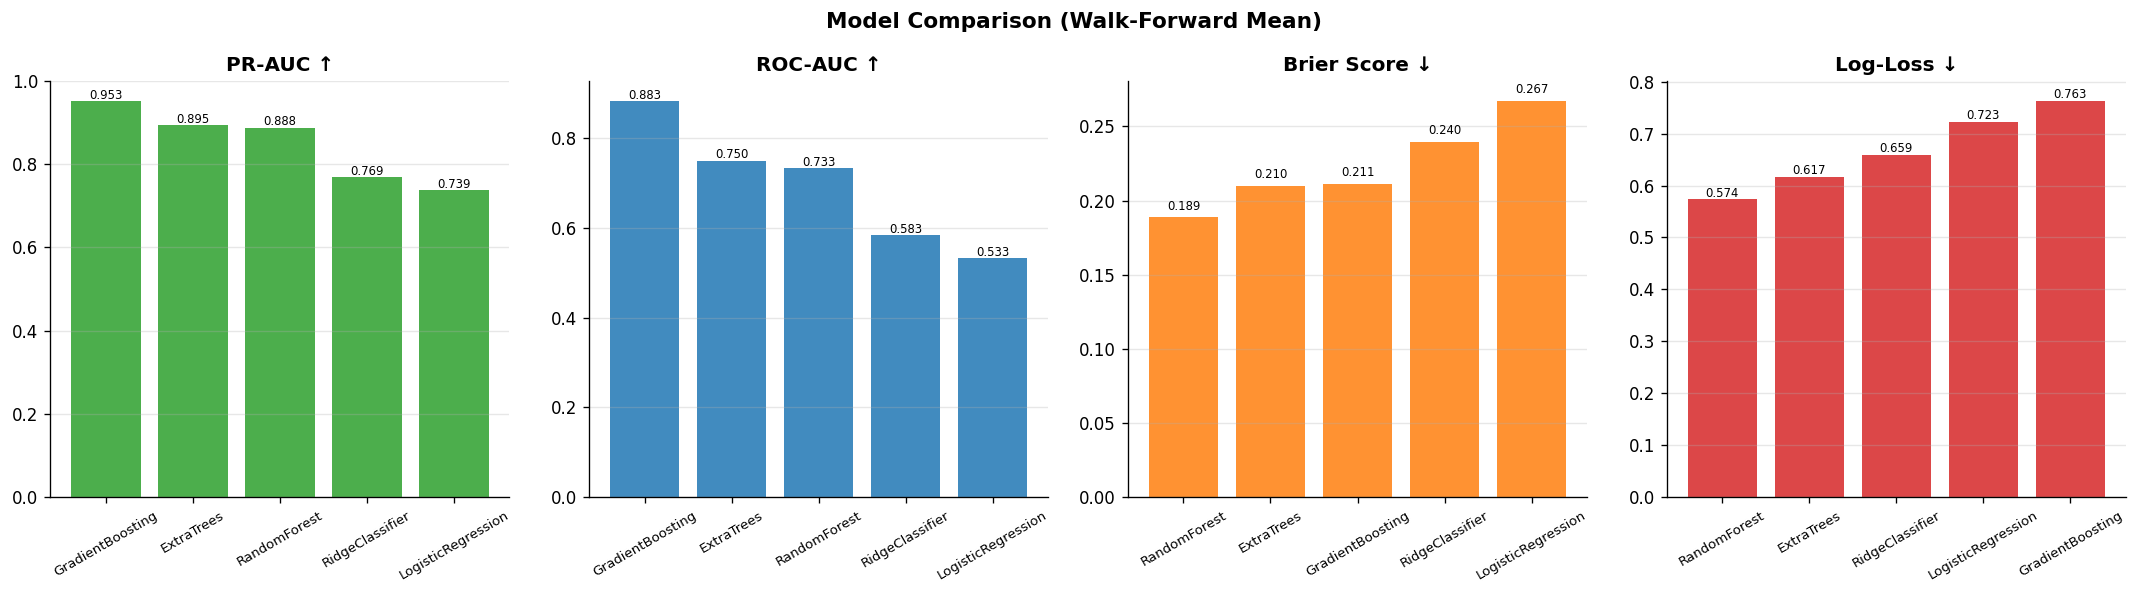

In [136]:
# ── Model comparison bar chart ─────────────────────────────────────────
metrics = ['pr_auc', 'roc_auc', 'brier', 'log_loss']
titles  = ['PR-AUC ↑', 'ROC-AUC ↑', 'Brier Score ↓', 'Log-Loss ↓']
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('Model Comparison (Walk-Forward Mean)', fontsize=13, fontweight='bold')

for ax, metric, title, colour in zip(axes, metrics, titles,
                                      ['#2ca02c','#1f77b4','#ff7f0e','#d62728']):
    vals = summary[metric].dropna().sort_values(ascending=(metric in ['brier','log_loss']))
    bars = ax.bar(vals.index, vals.values, color=colour, alpha=0.85)
    ax.set_title(title, fontweight='bold')
    ax.tick_params(axis='x', rotation=30, labelsize=8)
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, vals.values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                f'{val:.3f}', ha='center', fontsize=7)

plt.tight_layout(); plt.show()


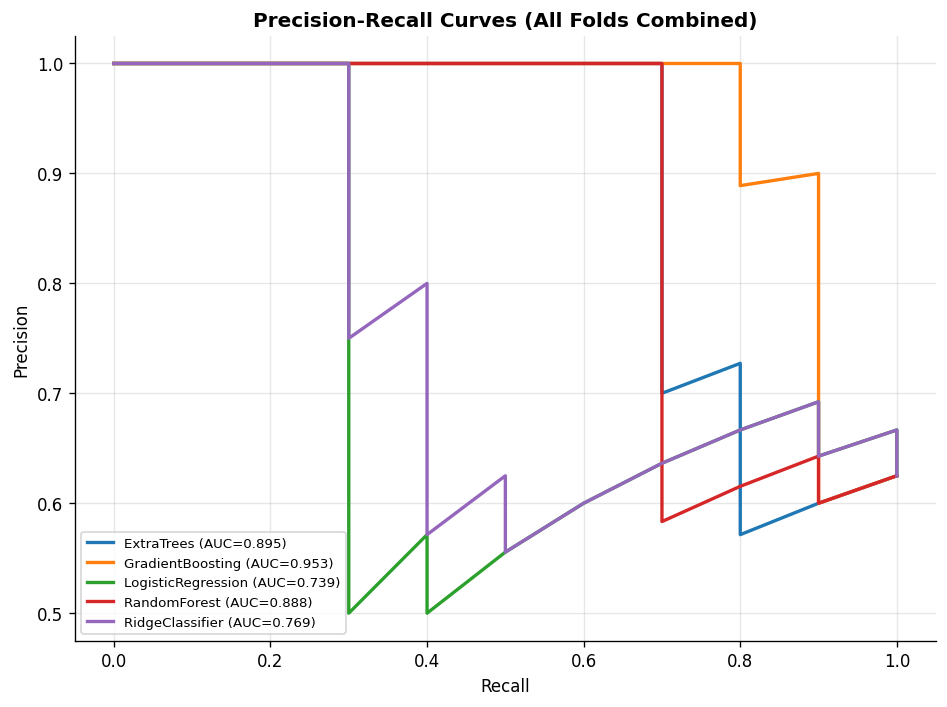

In [137]:
# ── Precision-Recall curves ────────────────────────────────────────────
from sklearn.metrics import precision_recall_curve, average_precision_score

fig, ax = plt.subplots(figsize=(8, 6))
ax.set_title('Precision-Recall Curves (All Folds Combined)', fontweight='bold')

for i, (model_name, grp) in enumerate(preds_df.groupby('model')):
    yt, yp = grp['y_true'].values, grp['y_prob'].values
    if yt.sum() == 0: continue
    prec, rec, _ = precision_recall_curve(yt, yp)
    auc_val = average_precision_score(yt, yp)
    ax.plot(rec, prec, linewidth=2, color=PALETTE[i%len(PALETTE)],
            label=f'{model_name} (AUC={auc_val:.3f})')

ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


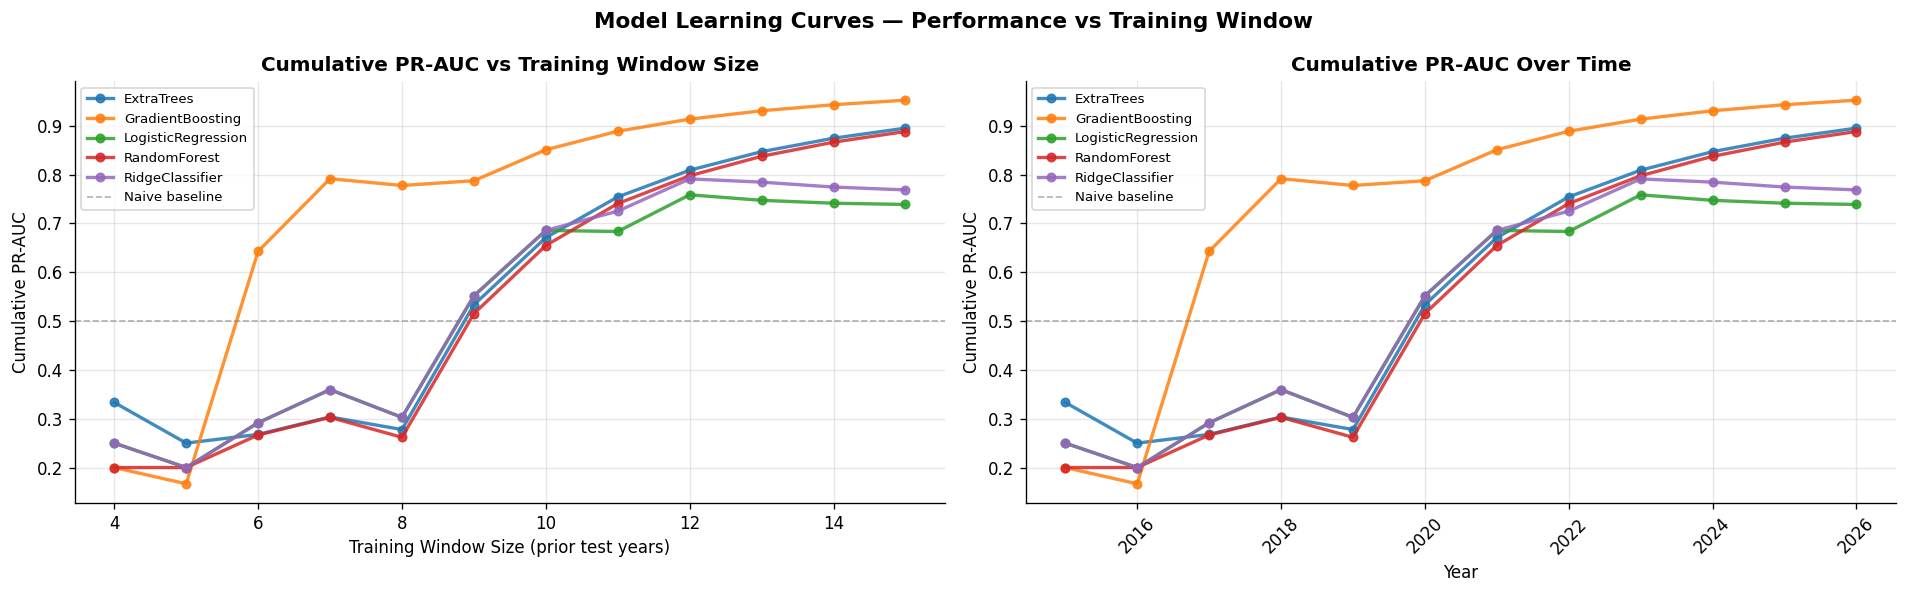

Rising curves = model improves as it sees more data; flat = stable generalisation


In [138]:
# ── 6D: Model learning curves — performance vs training window ─────────
from sklearn.metrics import average_precision_score

fold_lc = []
all_test_years = sorted(preds_df['year'].unique())

for mname, model_grp in preds_df.groupby('model'):
    model_grp_s = model_grp.sort_values('year')
    cum_yt, cum_yp = [], []
    for yr in all_test_years:
        yr_rows = model_grp_s[model_grp_s['year'] == yr]
        if yr_rows.empty:
            continue
        cum_yt.extend(yr_rows['y_true'].values)
        cum_yp.extend(yr_rows['y_prob'].values)
        train_sz = len([y for y in all_test_years if y < yr])
        if len(np.unique(cum_yt)) < 2 or train_sz < 1:
            continue
        try:
            auc = average_precision_score(cum_yt, cum_yp)
            fold_lc.append({'model': mname, 'year': yr,
                            'train_size': train_sz, 'pr_auc': auc})
        except Exception:
            pass

lc_df = pd.DataFrame(fold_lc).dropna()

if lc_df.empty:
    print('No learning-curve data to plot (insufficient class variety across folds).')
else:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle('Model Learning Curves — Performance vs Training Window',
                 fontsize=13, fontweight='bold')

    for i, (mname, grp) in enumerate(lc_df.groupby('model')):
        grp_s = grp.sort_values('train_size')
        axes[0].plot(grp_s['train_size'], grp_s['pr_auc'], 'o-', linewidth=2,
                     markersize=5, color=PALETTE[i % len(PALETTE)], label=mname, alpha=0.85)
    axes[0].axhline(0.5, color='grey', linestyle='--', linewidth=1, alpha=0.6,
                    label='Naive baseline')
    axes[0].set_title('Cumulative PR-AUC vs Training Window Size', fontweight='bold')
    axes[0].set_xlabel('Training Window Size (prior test years)')
    axes[0].set_ylabel('Cumulative PR-AUC')
    axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

    for i, (mname, grp) in enumerate(lc_df.groupby('model')):
        grp_s = grp.sort_values('year')
        axes[1].plot(grp_s['year'], grp_s['pr_auc'], 'o-', linewidth=2,
                     markersize=5, color=PALETTE[i % len(PALETTE)], label=mname, alpha=0.85)
    axes[1].axhline(0.5, color='grey', linestyle='--', linewidth=1, alpha=0.6,
                    label='Naive baseline')
    axes[1].set_title('Cumulative PR-AUC Over Time', fontweight='bold')
    axes[1].set_xlabel('Year'); axes[1].set_ylabel('Cumulative PR-AUC')
    axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)
    axes[1].tick_params(axis='x', rotation=45)

    plt.tight_layout(); plt.show()
    print('Rising curves = model improves as it sees more data; flat = stable generalisation')


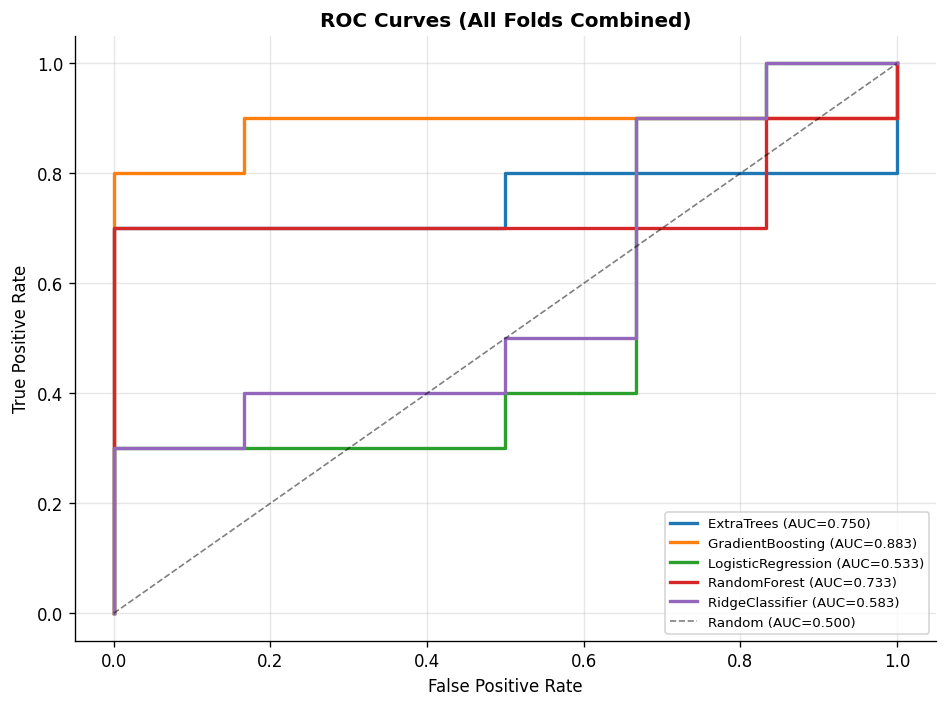

In [139]:
# ── 6A: ROC curves (all folds combined) ────────────────────────────────
from sklearn.metrics import roc_curve, roc_auc_score

fig, ax = plt.subplots(figsize=(8, 6))
ax.set_title('ROC Curves (All Folds Combined)', fontweight='bold')

for i, (model_name, grp) in enumerate(preds_df.groupby('model')):
    yt_r, yp_r = grp['y_true'].values, grp['y_prob'].values
    if len(np.unique(yt_r)) < 2:
        continue
    fpr, tpr, _ = roc_curve(yt_r, yp_r)
    auc_val = roc_auc_score(yt_r, yp_r)
    ax.plot(fpr, tpr, linewidth=2, color=PALETTE[i % len(PALETTE)],
            label=f'{model_name} (AUC={auc_val:.3f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Random (AUC=0.500)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


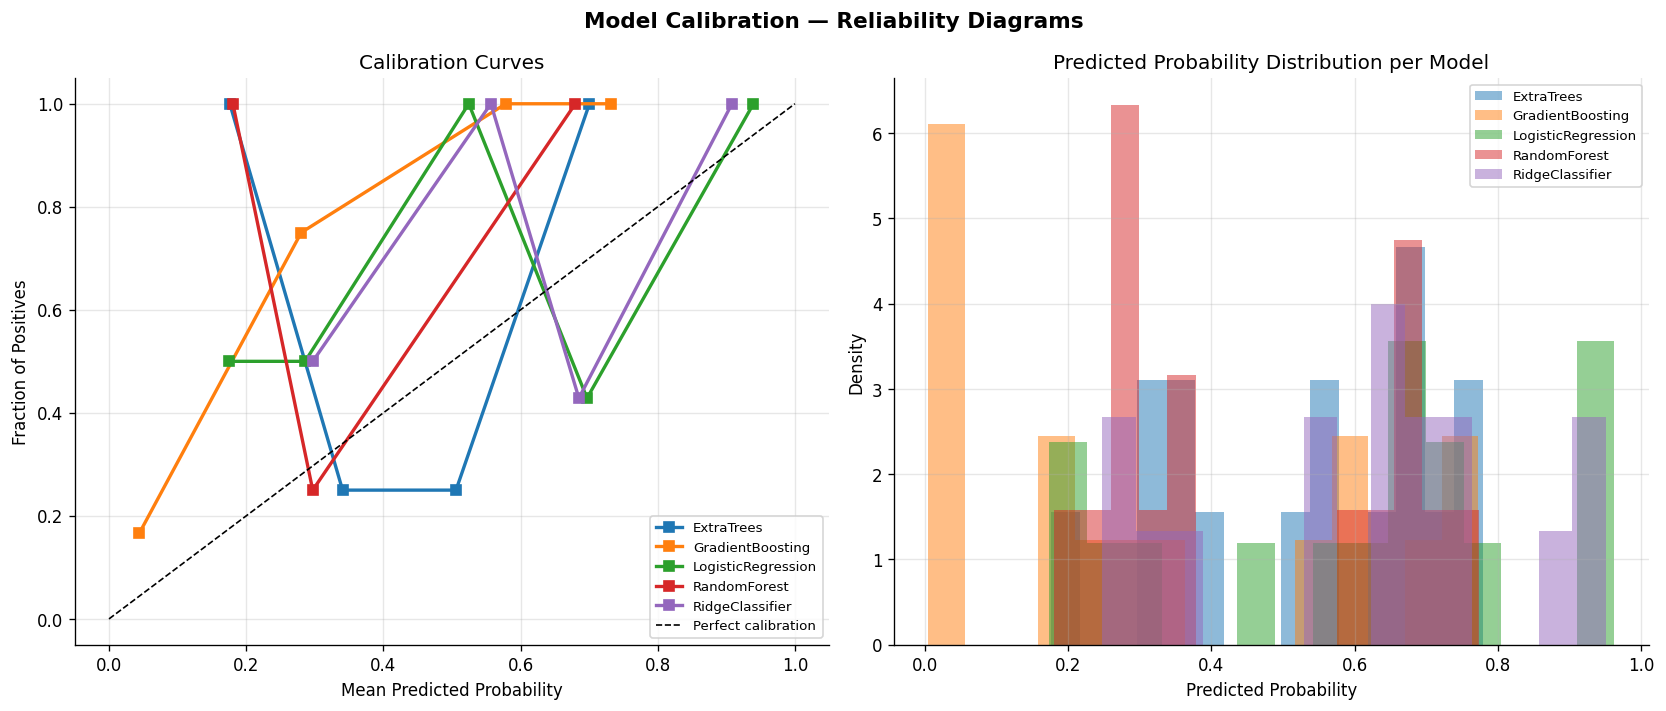

In [140]:
# ── 6B: Calibration (reliability) curves & probability distributions ───
from sklearn.calibration import calibration_curve

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Model Calibration — Reliability Diagrams', fontsize=13, fontweight='bold')

for i, (model_name, grp) in enumerate(preds_df.groupby('model')):
    yt_c, yp_c = grp['y_true'].values, grp['y_prob'].values
    if len(np.unique(yt_c)) < 2:
        continue
    try:
        n_bins = min(5, len(np.unique(np.round(yp_c, 1))))
        frac_pos, mean_pred = calibration_curve(yt_c, yp_c,
                                                n_bins=n_bins, strategy='uniform')
        ax1.plot(mean_pred, frac_pos, 's-', linewidth=2, markersize=6,
                 color=PALETTE[i % len(PALETTE)], label=model_name)
    except Exception:
        pass

ax1.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Perfect calibration')
ax1.set_xlabel('Mean Predicted Probability')
ax1.set_ylabel('Fraction of Positives')
ax1.set_title('Calibration Curves')
ax1.legend(fontsize=8); ax1.grid(alpha=0.3)

for i, (model_name, grp) in enumerate(preds_df.groupby('model')):
    ax2.hist(grp['y_prob'].values, bins=15, alpha=0.5, density=True,
             color=PALETTE[i % len(PALETTE)], label=model_name)

ax2.set_xlabel('Predicted Probability')
ax2.set_ylabel('Density')
ax2.set_title('Predicted Probability Distribution per Model')
ax2.legend(fontsize=8); ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()


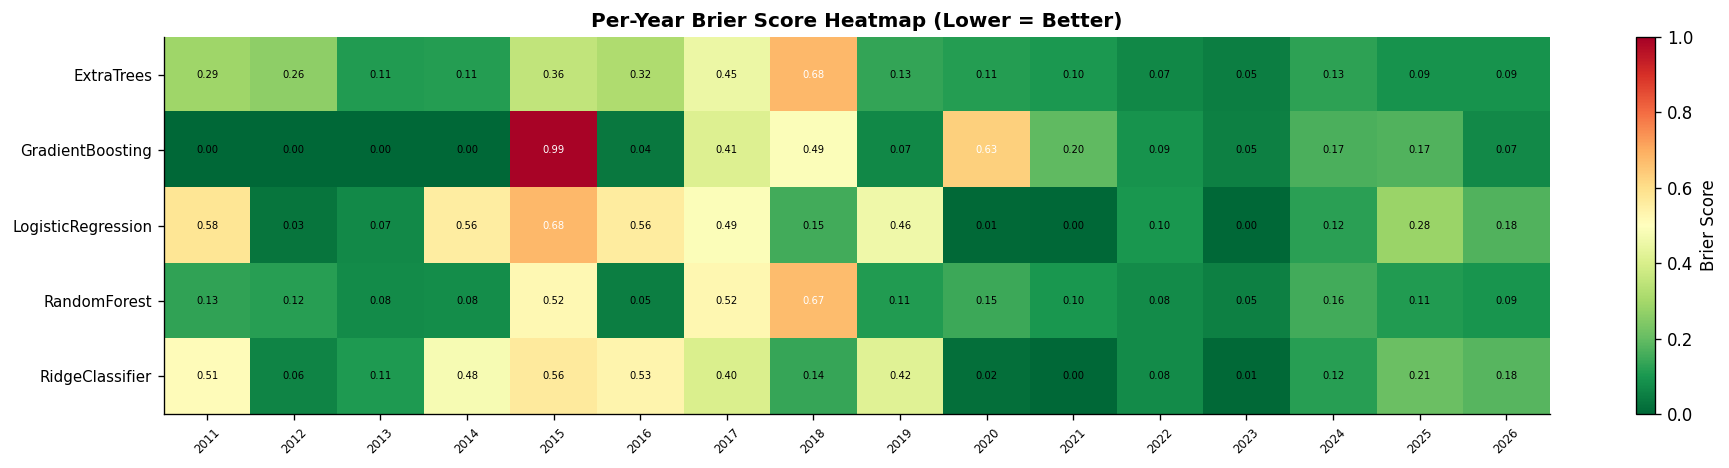

In [141]:
# ── 6C: Per-year Brier Score heatmap (model × year) ───────────────────
fold_rows = []
for (model_name, yr), grp in preds_df.groupby(['model', 'year']):
    yt_g, yp_g = grp['y_true'].values, grp['y_prob'].values
    fold_rows.append({'model': model_name, 'year': yr,
                      'brier': ((yt_g - yp_g) ** 2).mean()})
fold_metrics = pd.DataFrame(fold_rows)
pivot_brier = fold_metrics.pivot(index='model', columns='year', values='brier')

fig, ax = plt.subplots(figsize=(16, 4))
im = ax.imshow(pivot_brier.values, aspect='auto', cmap='RdYlGn_r', vmin=0, vmax=1)
ax.set_yticks(range(len(pivot_brier.index)))
ax.set_yticklabels(pivot_brier.index, fontsize=9)
ax.set_xticks(range(len(pivot_brier.columns)))
ax.set_xticklabels(pivot_brier.columns, rotation=45, fontsize=7)
ax.set_title('Per-Year Brier Score Heatmap (Lower = Better)',
             fontsize=12, fontweight='bold')
plt.colorbar(im, ax=ax, label='Brier Score')
for i in range(len(pivot_brier.index)):
    for j in range(len(pivot_brier.columns)):
        val = pivot_brier.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=6,
                    color='white' if val > 0.6 else 'black')
plt.tight_layout(); plt.show()


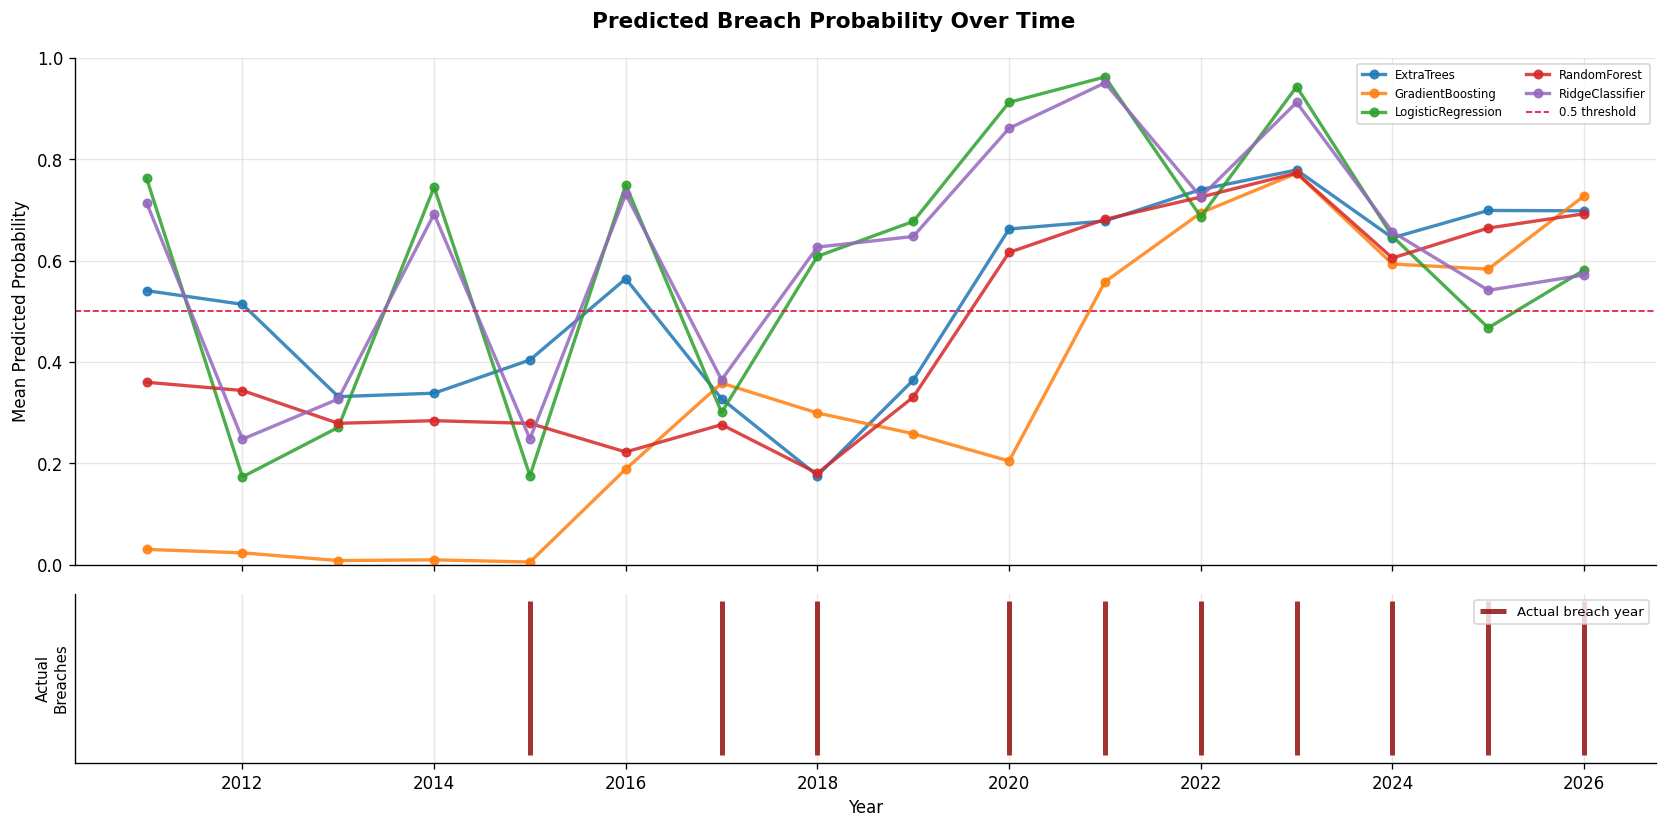

In [142]:
# ── Probability Timeline ───────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True,
                                gridspec_kw={'height_ratios':[3,1]})
fig.suptitle('Predicted Breach Probability Over Time', fontsize=13, fontweight='bold')

for i, (mname, grp) in enumerate(preds_df.groupby('model')):
    yr_prob = grp.groupby('year')['y_prob'].mean()
    ax1.plot(yr_prob.index, yr_prob.values, 'o-', linewidth=2, markersize=5,
             color=PALETTE[i%len(PALETTE)], label=mname, alpha=0.85)

ax1.axhline(0.5, color='crimson', linestyle='--', linewidth=1, label='0.5 threshold')
ax1.set_ylabel('Mean Predicted Probability')
ax1.legend(fontsize=7, ncol=2); ax1.grid(alpha=0.3); ax1.set_ylim(0, 1)

actual = preds_df.groupby('year')['y_true'].max()
ax2.vlines(actual[actual==1].index, 0, 1, color='darkred',
           linewidth=3, alpha=0.8, label='Actual breach year')
ax2.set_yticks([]); ax2.set_ylabel('Actual\nBreaches', fontsize=9)
ax2.set_xlabel('Year'); ax2.grid(alpha=0.3); ax2.legend(fontsize=8)

plt.tight_layout(); plt.show()


In [143]:
# ── Manual metric verification (Section 5.3 formulae) ─────────────────
from evaluation import brier_score, log_loss_manual

best_model_name = summary['pr_auc'].idxmax()
best_preds = preds_df[preds_df['model'] == best_model_name]
yt = best_preds['y_true'].values
yp = best_preds['y_prob'].values

print(f'Best model: {best_model_name}')
print(f'  Brier Score (manual):  {brier_score(yt, yp):.4f}')
print(f'  Log-Loss (manual):     {log_loss_manual(yt, yp):.4f}')
print(f'  PR-AUC:                {average_precision_score(yt, yp):.4f}')


Best model: GradientBoosting
  Brier Score (manual):  0.2113
  Log-Loss (manual):     0.7633
  PR-AUC:                0.9525


---
## 🧩 Stage 7 — Feature Explainability

Which societal/breach variables drive the model's predictions?

We use the **built-in feature importances** from Random Forest and
Gradient Boosting (tree-based SHAP equivalent).


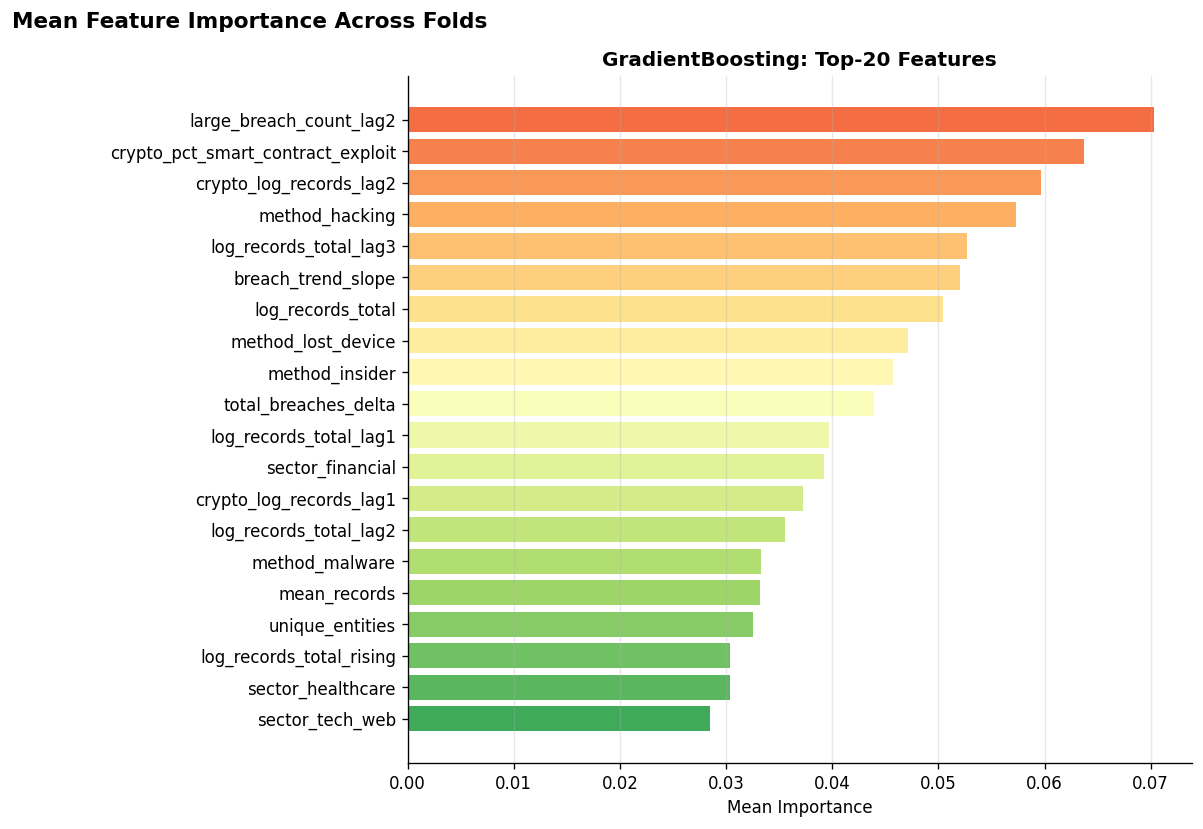

In [144]:
# ── Feature importance: RF ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Mean Feature Importance Across Folds', fontsize=13, fontweight='bold')

for ax, mname in zip(axes, ['RandomForest', 'GradientBoosting']):
    fi = wfv.mean_feature_importance(mname)
    if fi.empty: ax.set_visible(False); continue
    top = fi.head(20)
    colours = plt.cm.RdYlGn(np.linspace(0.2, 0.85, len(top)))
    ax.barh(top.index[::-1], top.values[::-1], color=colours[::-1])
    ax.set_title(f'{mname}: Top-20 Features', fontweight='bold')
    ax.set_xlabel('Mean Importance')
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout(); plt.show()


In [145]:
# ── Cumulative importance (Pareto) ─────────────────────────────────────
fi_rf = wfv.mean_feature_importance('RandomForest')
if not fi_rf.empty:
    cum = fi_rf.cumsum() / fi_rf.sum() * 100
    fig, ax = plt.subplots(figsize=(11, 4))
    ax.bar(range(len(fi_rf)), fi_rf.values / fi_rf.sum() * 100,
           color='#1f77b4', alpha=0.7, label='Individual importance')
    ax2_twin = ax.twinx()
    ax2_twin.plot(range(len(cum)), cum.values, 'r-o', markersize=3, linewidth=2,
                  label='Cumulative')
    ax2_twin.axhline(80, color='grey', linestyle='--', linewidth=0.8)
    ax.set_xticks(range(len(fi_rf)))
    ax.set_xticklabels(fi_rf.index, rotation=90, fontsize=7)
    ax.set_ylabel('Individual Importance (%)')
    ax2_twin.set_ylabel('Cumulative Importance (%)')
    ax.set_title('Random Forest — Pareto Feature Importance', fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    n80 = (cum < 80).sum() + 1
    print(f'Features needed to explain 80% of variance: {n80}')
    plt.tight_layout(); plt.show()


In [146]:
# ── SHAP-style signed contribution (permutation approximation) ─────────
# We compute mean(pred | feat=high) - mean(pred | feat=low) for top features
best_fitted = wfv.best_models.get('RandomForest') or wfv.best_models.get('GradientBoosting')
if best_fitted is not None:
    fi_vals = wfv.mean_feature_importance('RandomForest')
    top_feats = fi_vals.head(8).index.tolist()

    signed_impacts = {}
    for feat in top_feats:
        if feat not in X.columns: continue
        X_hi = X.copy(); X_hi[feat] = X[feat].quantile(0.75)
        X_lo = X.copy(); X_lo[feat] = X[feat].quantile(0.25)
        try:
            p_hi = best_fitted.predict_proba(X_hi)[:, 1].mean()
            p_lo = best_fitted.predict_proba(X_lo)[:, 1].mean()
            signed_impacts[feat] = p_hi - p_lo
        except: pass

    si = pd.Series(signed_impacts).sort_values()
    colours = ['#d62728' if v > 0 else '#1f77b4' for v in si.values]
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.barh(si.index, si.values, color=colours)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Δ Predicted Probability (75th - 25th percentile)')
    ax.set_title('Directional Feature Impact (SHAP-Style Approximation)',
                 fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout(); plt.show()
    print('\nRed = feature increase RAISES breach probability')
    print('Blue = feature increase LOWERS breach probability')


In [147]:
# ── 7D: Feature importance comparison — RF vs GradientBoosting ─────────
fi_rf = wfv.mean_feature_importance('RandomForest')
fi_gb = wfv.mean_feature_importance('GradientBoosting')

if not fi_rf.empty and not fi_gb.empty:
    combined_imp = (fi_rf.add(fi_gb, fill_value=0)).sort_values(ascending=False).head(15)
    top_feats_cmp = combined_imp.index.tolist()
    rf_vals = fi_rf.reindex(top_feats_cmp, fill_value=0).values
    gb_vals = fi_gb.reindex(top_feats_cmp, fill_value=0).values

    x_pos = np.arange(len(top_feats_cmp))
    width = 0.38

    fig, ax = plt.subplots(figsize=(13, 6))
    ax.bar(x_pos - width / 2, rf_vals, width,
           label='RandomForest', color='#1f77b4', alpha=0.85)
    ax.bar(x_pos + width / 2, gb_vals, width,
           label='GradientBoosting', color='#ff7f0e', alpha=0.85)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(top_feats_cmp, rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('Mean Feature Importance')
    ax.set_title('Feature Importance Comparison: Random Forest vs Gradient Boosting',
                 fontweight='bold')
    ax.legend(fontsize=10); ax.grid(axis='y', alpha=0.3)
    plt.tight_layout(); plt.show()


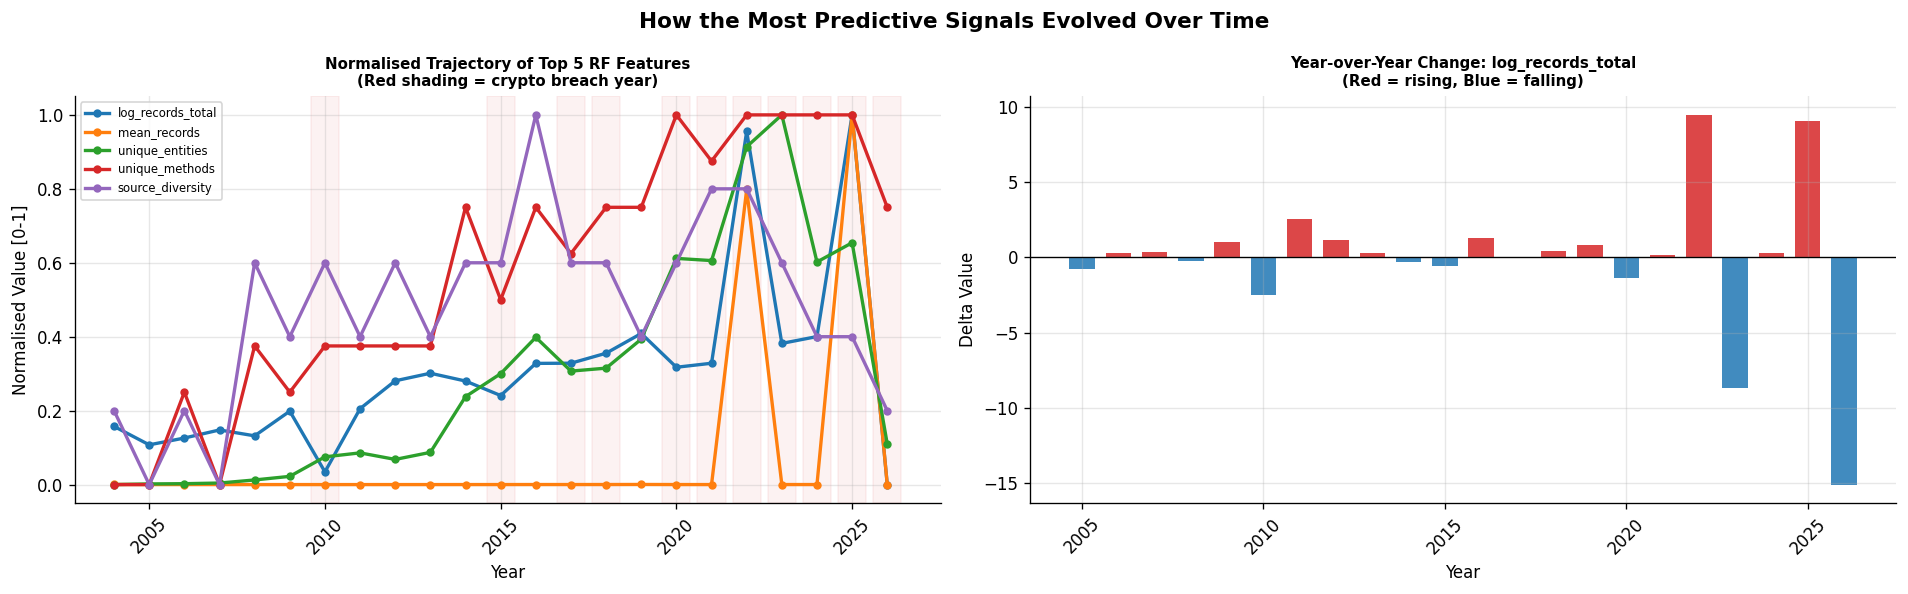

Top feature tracked: log_records_total
(Feature importance unavailable; showing top X columns as fallback)


In [148]:
# ── 7E: Top feature drift over prediction years ────────────────────────
fi_rf = wfv.mean_feature_importance('RandomForest')
if fi_rf.empty:
    top5_drift = list(X.columns[:5])
else:
    top5_drift = fi_rf.head(5).index.tolist()

if not top5_drift:
    print('No feature importance data available for drift analysis.')
else:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle('How the Most Predictive Signals Evolved Over Time',
                 fontsize=13, fontweight='bold')

    ax = axes[0]
    for i, feat in enumerate(top5_drift):
        src = yearly_df if feat in yearly_df.columns else X
        if feat not in src.columns:
            continue
        vals = src[feat].astype(float)
        rng = vals.max() - vals.min()
        vals_norm = (vals - vals.min()) / (rng if rng > 0 else 1)
        ax.plot(vals_norm.index, vals_norm.values, 'o-', linewidth=2,
                color=PALETTE[i % len(PALETTE)], label=feat, markersize=4)
    for yr in yearly_df.index[y == 1]:
        ax.axvspan(yr - 0.4, yr + 0.4, color='#d62728', alpha=0.06)
    ax.set_title('Normalised Trajectory of Top 5 RF Features\n(Red shading = crypto breach year)',
                 fontweight='bold', fontsize=9)
    ax.set_xlabel('Year'); ax.set_ylabel('Normalised Value [0-1]')
    ax.legend(fontsize=7); ax.grid(alpha=0.3)
    ax.tick_params(axis='x', rotation=45)

    top_feat = top5_drift[0]
    src = yearly_df if top_feat in yearly_df.columns else X
    if top_feat in src.columns:
        delta = src[top_feat].astype(float).diff().dropna()
        colours_d = ['#d62728' if v > 0 else '#1f77b4' for v in delta.values]
        axes[1].bar(delta.index, delta.values, color=colours_d, alpha=0.85, width=0.7)
        axes[1].axhline(0, color='black', linewidth=0.8)
        axes[1].set_title(f'Year-over-Year Change: {top_feat}\n(Red = rising, Blue = falling)',
                          fontweight='bold', fontsize=9)
        axes[1].set_xlabel('Year'); axes[1].set_ylabel('Delta Value')
        axes[1].grid(alpha=0.3)
        axes[1].tick_params(axis='x', rotation=45)
    else:
        axes[1].set_visible(False)

    plt.tight_layout(); plt.show()
    print(f'Top feature tracked: {top_feat}')
    if fi_rf.empty:
        print('(Feature importance unavailable; showing top X columns as fallback)')

In [149]:
# ── 7F: Feature importance stability across folds ─────────────────────
fold_fi_rows = []
for result in wfv.all_results:
    if result.model_name != 'RandomForest':
        continue
    if not result.feature_importance:
        continue
    row = dict(result.feature_importance)
    row['year'] = result.test_years[0]
    fold_fi_rows.append(row)

fi_rf_mean = wfv.mean_feature_importance('RandomForest')
if not fi_rf_mean.empty:
    top10_feats = fi_rf_mean.head(10).index.tolist()
elif fold_fi_rows:
    top10_feats = [k for k in fold_fi_rows[0] if k != 'year'][:10]
else:
    top10_feats = list(X.columns[:10])

if fold_fi_rows and top10_feats:
    available = [f for f in top10_feats if f in fold_fi_rows[0]]
    fold_fi_df = pd.DataFrame(fold_fi_rows).set_index('year')[available]
    # ... plotting code (same as before, using `available` instead of `top10_feats`)
else:
    print('Per-fold importances not available for RandomForest.')


Per-fold importances not available for RandomForest.


---
## 🚨 Stage 8 — Risk Scoring & Alerts

Generate a **probability-based risk tier** for any given year's features.

| Tier | Probability | Action |
|------|-------------|--------|
| 🟢 LOW | < 40% | Routine monitoring |
| 🟡 ELEVATED | 40–60% | Enhanced vigilance |
| 🟠 HIGH | 60–80% | Active defence posture |
| 🔴 CRITICAL | ≥ 80% | Incident response readiness |


In [150]:
def risk_tier(prob):
    if prob >= 0.80: return '🔴 CRITICAL'
    if prob >= 0.60: return '🟠 HIGH'
    if prob >= 0.40: return '🟡 ELEVATED'
    return '🟢 LOW'

best_model_name = summary['pr_auc'].idxmax()
scored = preds_df[preds_df['model'] == best_model_name].copy()
scored['tier'] = scored['y_prob'].apply(risk_tier)

display(HTML(f'<b>Risk Scores — {best_model_name}</b>'))
display(
    scored[['year','y_prob','tier','y_true']]
    .rename(columns={'y_prob':'probability','y_true':'actual_breach'})
    .set_index('year')
    .style
    .background_gradient(subset=['probability'], cmap='RdYlGn_r')
    .map(lambda v: 'color: red; font-weight: bold' if v == 1 else '',
         subset=['actual_breach'])
    .format({'probability': '{:.1%}'})
)

,probability,tier,actual_breach
year,,,
2011,3.0%,🟢 LOW,0
2012,2.3%,🟢 LOW,0
2013,0.8%,🟢 LOW,0
2014,1.0%,🟢 LOW,0
2015,0.5%,🟢 LOW,1
2016,18.9%,🟢 LOW,0
2017,35.8%,🟢 LOW,1
2018,30.0%,🟢 LOW,1
2019,25.9%,🟢 LOW,0


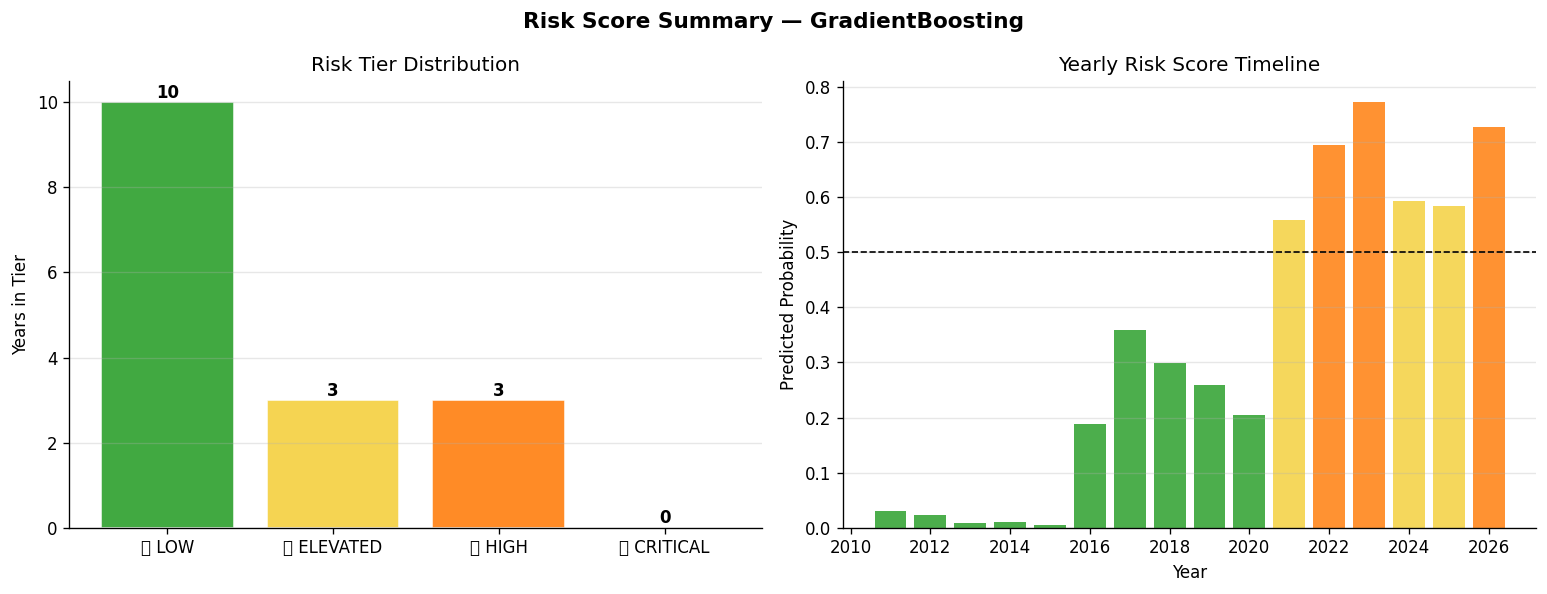

In [151]:
# ── Risk tier distribution visualisation ──────────────────────────────
tier_order = ['🟢 LOW', '🟡 ELEVATED', '🟠 HIGH', '🔴 CRITICAL']
tier_cnt   = scored['tier'].value_counts().reindex(tier_order, fill_value=0)
tier_col   = ['#2ca02c', '#f4d03f', '#ff7f0e', '#d62728']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f'Risk Score Summary — {best_model_name}', fontsize=13, fontweight='bold')

ax1.bar(tier_order, tier_cnt.values, color=tier_col, alpha=0.9, edgecolor='white')
ax1.set_ylabel('Years in Tier'); ax1.set_title('Risk Tier Distribution')
ax1.grid(axis='y', alpha=0.3)
for i, (v, label) in enumerate(zip(tier_cnt.values, tier_order)):
    ax1.text(i, v+0.1, str(v), ha='center', fontweight='bold')

yr_prob_best = scored.set_index('year')['y_prob'].sort_index()
colours_line = [tier_col[['🟢 LOW','🟡 ELEVATED','🟠 HIGH','🔴 CRITICAL'].index(
                risk_tier(p))] for p in yr_prob_best.values]
ax2.bar(yr_prob_best.index, yr_prob_best.values, color=colours_line, alpha=0.85)
ax2.axhline(0.5, color='black', linestyle='--', linewidth=1)
ax2.set_xlabel('Year'); ax2.set_ylabel('Predicted Probability')
ax2.set_title('Yearly Risk Score Timeline')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout(); plt.show()


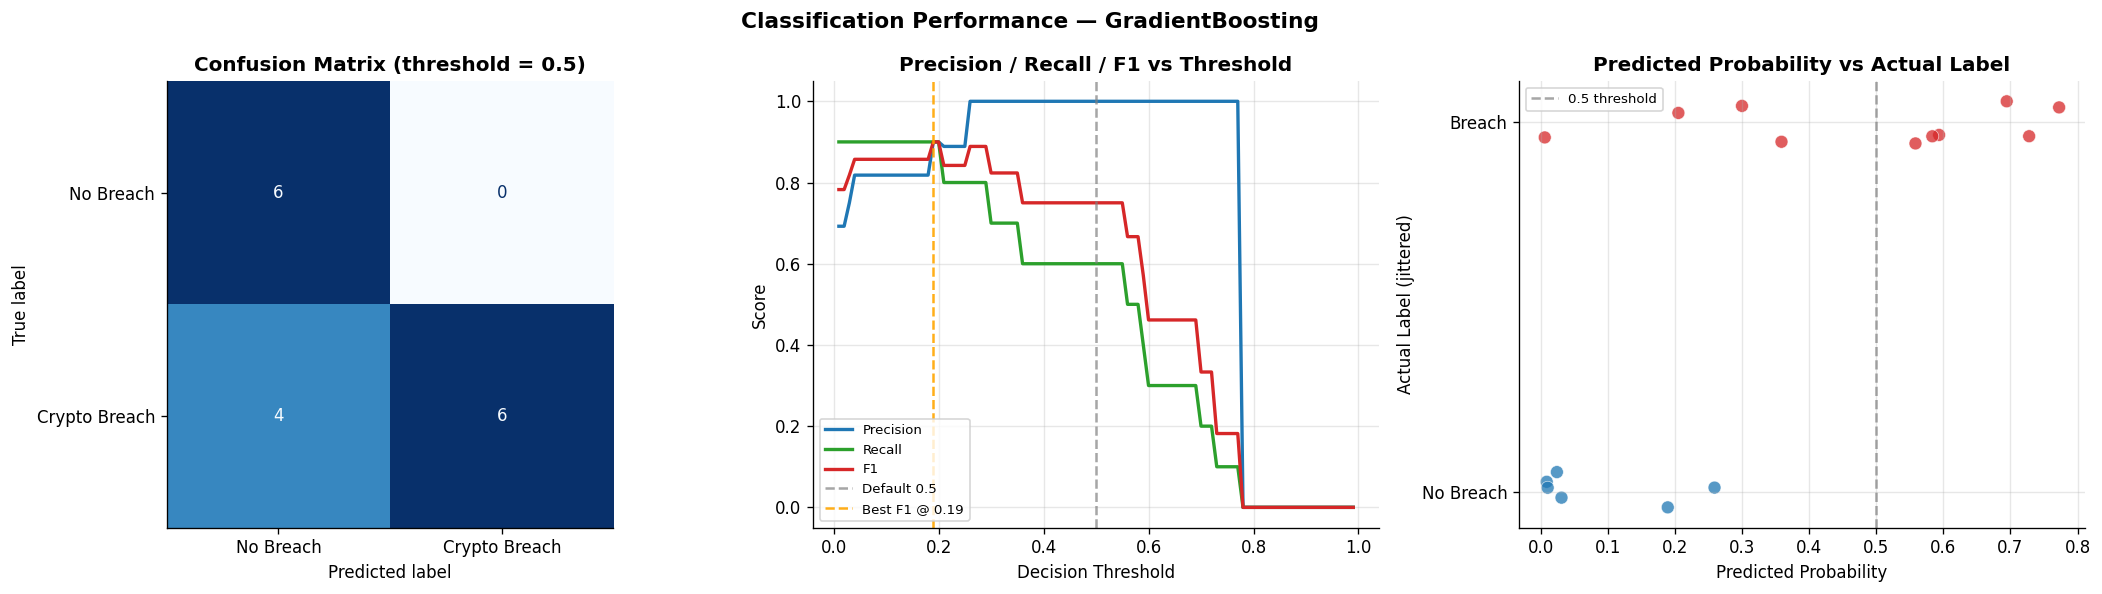

Best F1 decision threshold: 0.19


In [152]:
# ── 8B: Confusion matrix, threshold analysis & probability scatter ──────
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

yt_s = scored['y_true'].values
yp_s = scored['y_prob'].values
yhat_s = (yp_s >= 0.5).astype(int)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'Classification Performance — {best_model_name}',
             fontsize=13, fontweight='bold')

# Confusion matrix at threshold 0.5
cm = confusion_matrix(yt_s, yhat_s)
disp = ConfusionMatrixDisplay(cm, display_labels=['No Breach', 'Crypto Breach'])
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix (threshold = 0.5)', fontweight='bold')

# Precision / Recall / F1 vs threshold
thresholds = np.linspace(0.01, 0.99, 99)
precisions, recalls, f1s = [], [], []
for thr in thresholds:
    pred = (yp_s >= thr).astype(int)
    tp = ((pred == 1) & (yt_s == 1)).sum()
    fp = ((pred == 1) & (yt_s == 0)).sum()
    fn = ((pred == 0) & (yt_s == 1)).sum()
    p = tp / (tp + fp + 1e-9)
    r = tp / (tp + fn + 1e-9)
    precisions.append(p)
    recalls.append(r)
    f1s.append(2 * p * r / (p + r + 1e-9))

best_f1_thr = thresholds[np.argmax(f1s)]
axes[1].plot(thresholds, precisions, label='Precision', color='#1f77b4', linewidth=2)
axes[1].plot(thresholds, recalls,    label='Recall',    color='#2ca02c', linewidth=2)
axes[1].plot(thresholds, f1s,        label='F1',        color='#d62728', linewidth=2)
axes[1].axvline(0.5, color='grey', linestyle='--', alpha=0.7, label='Default 0.5')
axes[1].axvline(best_f1_thr, color='orange', linestyle='--', alpha=0.9,
                label=f'Best F1 @ {best_f1_thr:.2f}')
axes[1].set_xlabel('Decision Threshold'); axes[1].set_ylabel('Score')
axes[1].set_title('Precision / Recall / F1 vs Threshold', fontweight='bold')
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

# Predicted probability vs actual (jittered)
rng = np.random.RandomState(42)
jitter = rng.uniform(-0.06, 0.06, len(yp_s))
scatter_cols = ['#d62728' if v else '#1f77b4' for v in yt_s]
axes[2].scatter(yp_s, yt_s + jitter, c=scatter_cols, s=60,
                alpha=0.75, edgecolors='white', linewidths=0.4)
axes[2].axvline(0.5, color='grey', linestyle='--', alpha=0.7, label='0.5 threshold')
axes[2].set_xlabel('Predicted Probability')
axes[2].set_ylabel('Actual Label (jittered)')
axes[2].set_yticks([0, 1])
axes[2].set_yticklabels(['No Breach', 'Breach'])
axes[2].set_title('Predicted Probability vs Actual Label', fontweight='bold')
axes[2].legend(fontsize=8); axes[2].grid(alpha=0.3)

plt.tight_layout(); plt.show()
print(f'Best F1 decision threshold: {best_f1_thr:.2f}')


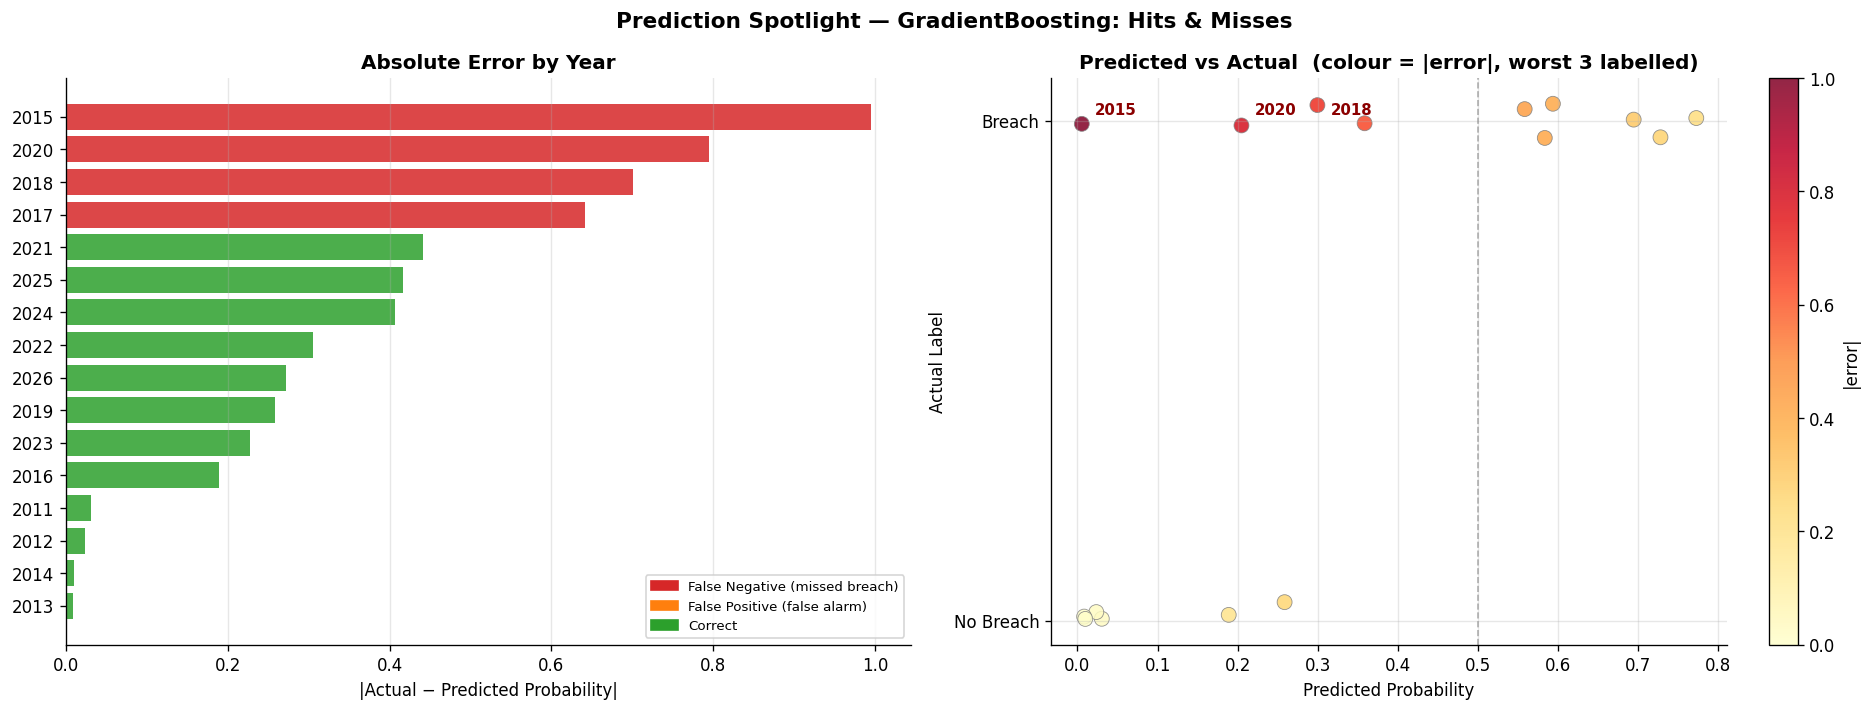


Top-5 hardest years to predict:
 year  actual  predicted    error                            type
 2015       1   0.005353 0.994647 False Negative\n(missed breach)
 2020       1   0.204684 0.795316 False Negative\n(missed breach)
 2018       1   0.299505 0.700495 False Negative\n(missed breach)
 2017       1   0.358452 0.641548 False Negative\n(missed breach)
 2021       1   0.558287 0.441713                         Correct


In [153]:
# ── 8C: Prediction spotlight — where did the model miss? ──────────────
from matplotlib.patches import Patch as MPatch

yt_s   = scored['y_true'].values
yp_s   = scored['y_prob'].values
yrs_s  = scored['year'].values
errors = np.abs(yt_s - yp_s)

def miss_type(actual, pred):
    if actual == 1 and pred < 0.5:  return 'False Negative\n(missed breach)'
    if actual == 0 and pred >= 0.5: return 'False Positive\n(false alarm)'
    return 'Correct'

miss_col = {'False Negative\n(missed breach)': '#d62728',
            'False Positive\n(false alarm)':   '#ff7f0e',
            'Correct':                          '#2ca02c'}

err_df = pd.DataFrame({
    'year': yrs_s, 'actual': yt_s,
    'predicted': yp_s, 'error': errors,
    'type': [miss_type(a, p) for a, p in zip(yt_s, yp_s)]
}).sort_values('error', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f'Prediction Spotlight — {best_model_name}: Hits & Misses',
             fontsize=13, fontweight='bold')

# Left: horizontal error bar per year, colour = miss type
bar_cols = [miss_col[t] for t in err_df['type']]
axes[0].barh(err_df['year'].astype(str), err_df['error'],
             color=bar_cols, alpha=0.85)
axes[0].set_title('Absolute Error by Year', fontweight='bold')
axes[0].set_xlabel('|Actual − Predicted Probability|')
axes[0].grid(axis='x', alpha=0.3)
leg_h = [MPatch(color=c, label=l.replace('\n', ' ')) for l, c in miss_col.items()]
axes[0].legend(handles=leg_h, fontsize=8, loc='lower right')

# Right: scatter of predicted vs actual, worst 3 labelled
sc = axes[1].scatter(yp_s, yt_s + np.random.RandomState(0).uniform(-0.04, 0.04, len(yt_s)),
                     s=80, c=errors, cmap='YlOrRd',
                     alpha=0.85, edgecolors='grey', linewidths=0.5,
                     vmin=0, vmax=1)
plt.colorbar(sc, ax=axes[1], label='|error|')
axes[1].axvline(0.5, color='grey', linestyle='--', linewidth=1, alpha=0.6)
axes[1].set_xlabel('Predicted Probability')
axes[1].set_ylabel('Actual Label')
axes[1].set_yticks([0, 1]); axes[1].set_yticklabels(['No Breach', 'Breach'])
axes[1].set_title('Predicted vs Actual  (colour = |error|, worst 3 labelled)',
                  fontweight='bold')
axes[1].grid(alpha=0.3)
for _, row in err_df.nlargest(3, 'error').iterrows():
    axes[1].annotate(str(int(row['year'])),
                     xy=(row['predicted'], row['actual']),
                     xytext=(8, 4), textcoords='offset points',
                     fontsize=9, color='darkred', fontweight='bold')

plt.tight_layout(); plt.show()
print('\nTop-5 hardest years to predict:')
print(err_df.nlargest(5, 'error')[['year', 'actual', 'predicted', 'error', 'type']]
      .to_string(index=False))


In [154]:
# ── Final summary printout ─────────────────────────────────────────────
from sklearn.metrics import brier_score_loss, log_loss, average_precision_score

yt = scored['y_true'].values
yp = scored['y_prob'].values

print('=' * 55)
print(f'  FINAL EVALUATION — {best_model_name}')
print('=' * 55)
print(f'  Brier Score : {brier_score_loss(yt, yp):.4f}')
print(f'  Log Loss    : {log_loss(yt, yp):.4f}')
print(f'  PR-AUC      : {average_precision_score(yt, yp):.4f}')
print('='*55)
print(f'\n  Records processed from ALL sources: {len(df):,}')
print(f'  Crypto-related incidents flagged:   {df["is_crypto"].sum():,}')
print(f'  Feature dimensions:                 {X.shape[1]}')
print(f'  Walk-forward folds:                 {len(wfv.all_results) // (len(models)+1)}')


  FINAL EVALUATION — GradientBoosting
  Brier Score : 0.2113
  Log Loss    : 0.7633
  PR-AUC      : 0.9525

  Records processed from ALL sources: 19,964
  Crypto-related incidents flagged:   1,650
  Feature dimensions:                 37
  Walk-forward folds:                 13


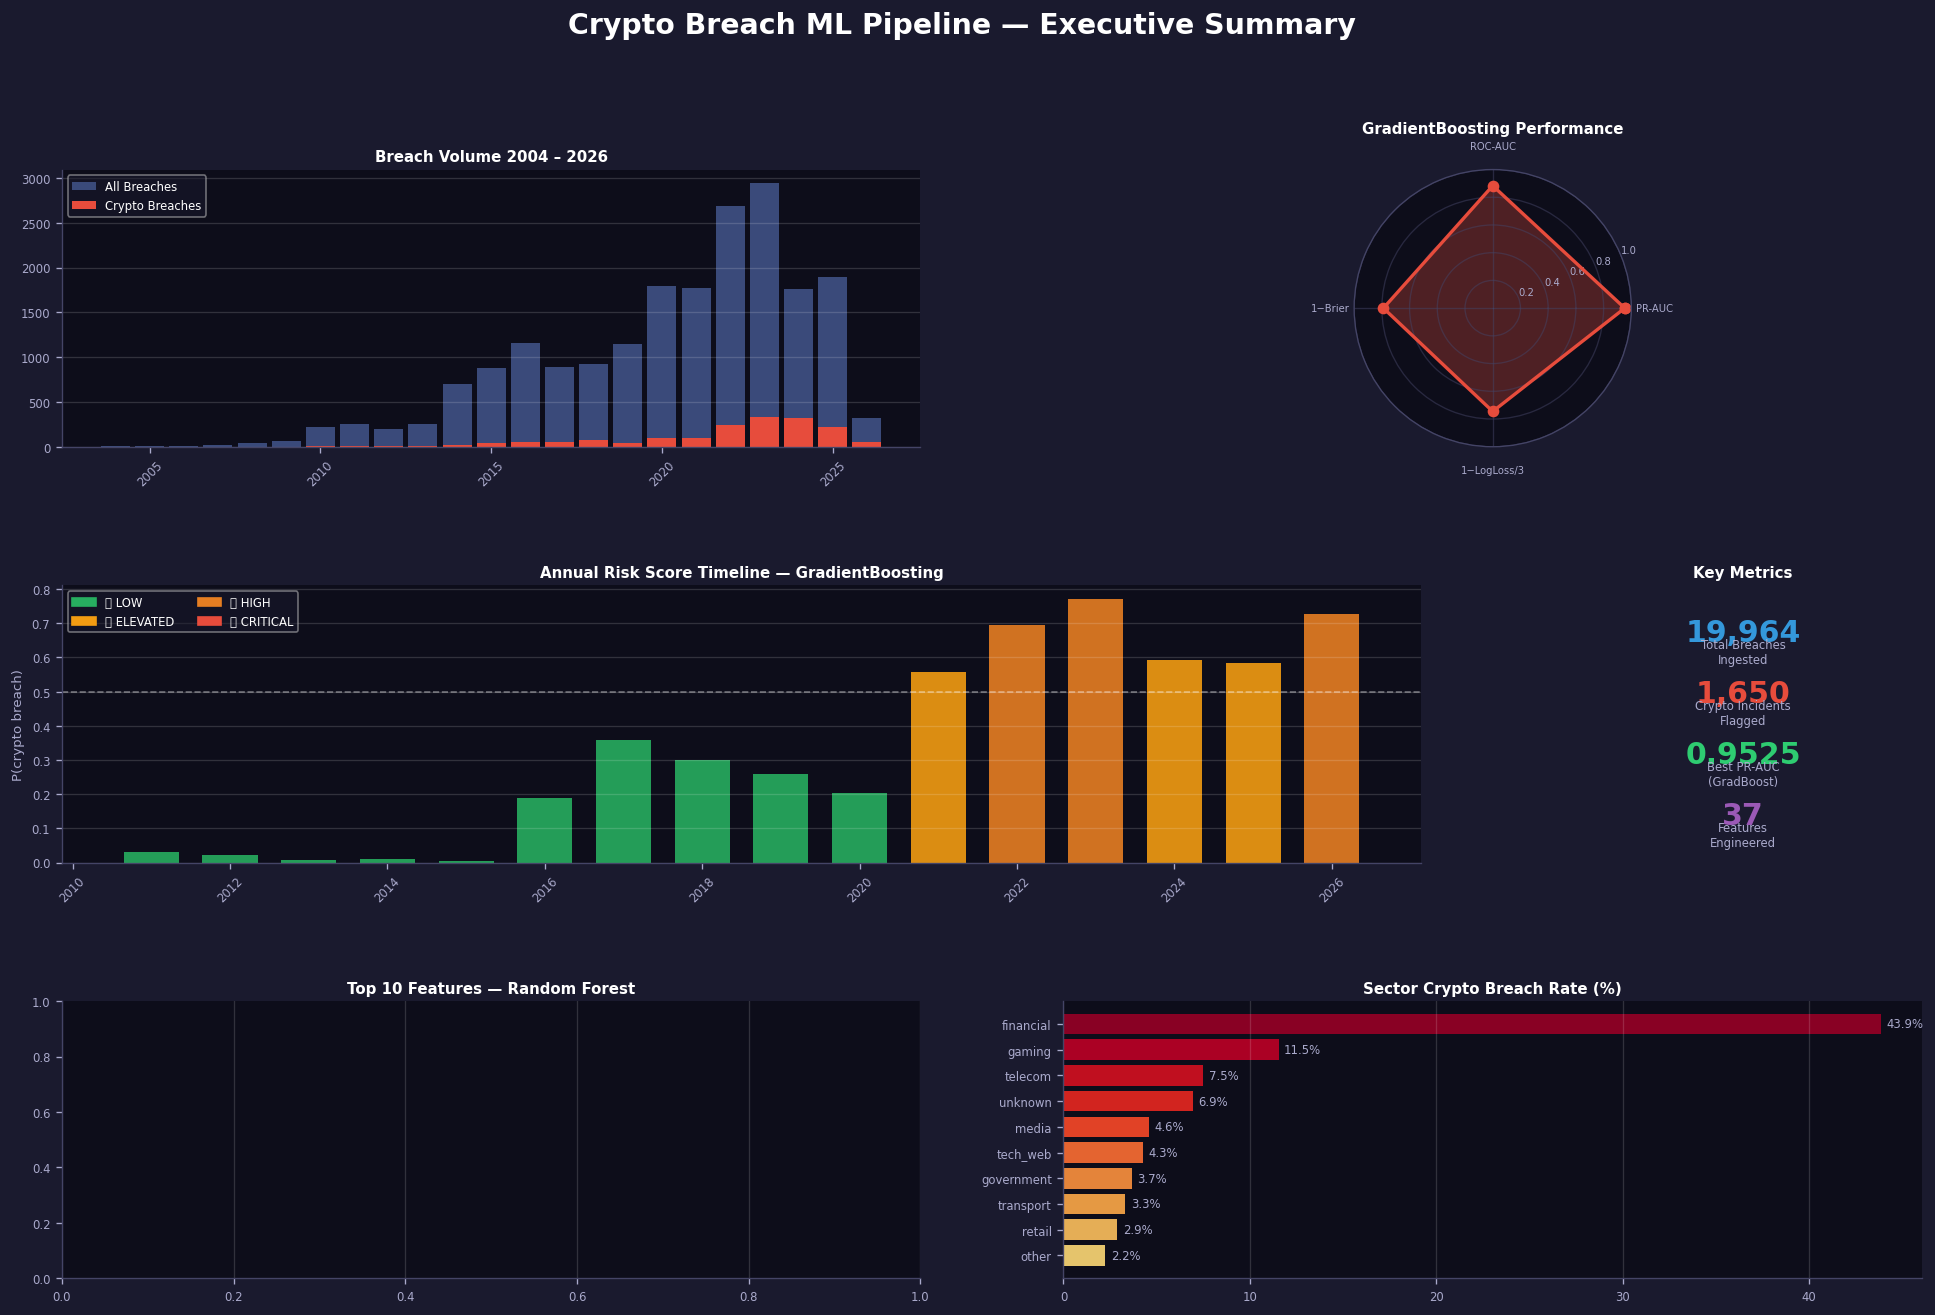

Dashboard saved → executive_summary_dashboard.png


In [155]:
# ── Executive Summary Dashboard ────────────────────────────────────────
from matplotlib.patches import Patch

BG   = '#1a1a2e'
PAN  = '#0d0d1a'
EDGE = '#444466'
TXT  = 'white'
SUB  = '#aaaacc'

fig = plt.figure(figsize=(20, 12), facecolor=BG)
gs  = gridspec.GridSpec(3, 4, figure=fig, hspace=0.50, wspace=0.40)

def style_ax(ax):
    ax.set_facecolor(PAN)
    for sp in ax.spines.values():
        sp.set_color(EDGE)
    ax.tick_params(colors=SUB, labelsize=7)
    ax.xaxis.label.set_color(SUB)
    ax.yaxis.label.set_color(SUB)

title_kw = dict(fontsize=9, fontweight='bold', color=TXT, pad=5)

# ── A: Breach volume 2004–2026 ─────────────────────────────────────────
ax_a = fig.add_subplot(gs[0, :2])
yr_total  = df.groupby('year').size()
yr_crypto = (df[df['is_crypto']].groupby('year').size()
             .reindex(yr_total.index, fill_value=0))
ax_a.bar(yr_total.index,  yr_total.values,  color='#3a4a7a', label='All Breaches',    width=0.85)
ax_a.bar(yr_crypto.index, yr_crypto.values, color='#e74c3c', label='Crypto Breaches', width=0.85)
ax_a.set_title('Breach Volume 2004 – 2026', **title_kw)
ax_a.legend(fontsize=7, facecolor=BG, labelcolor=TXT, framealpha=0.5)
ax_a.grid(axis='y', alpha=0.15, color=TXT)
ax_a.tick_params(axis='x', rotation=45)
style_ax(ax_a)

# ── B: Model performance radar ─────────────────────────────────────────
ax_b = fig.add_subplot(gs[0, 2:], polar=True)
radar_labels = ['PR-AUC', 'ROC-AUC', '1−Brier', '1−LogLoss/3']
gb_row = summary.loc['GradientBoosting'] if 'GradientBoosting' in summary.index else summary.iloc[0]
rv = [gb_row.get('pr_auc', 0), gb_row.get('roc_auc', 0),
      1 - gb_row.get('brier', 0), 1 - gb_row.get('log_loss', 0) / 3]
angles = np.linspace(0, 2 * np.pi, len(radar_labels), endpoint=False).tolist()
rv_plot = rv + rv[:1]; ang_plot = angles + angles[:1]
ax_b.plot(ang_plot, rv_plot, 'o-', linewidth=2, color='#e74c3c')
ax_b.fill(ang_plot, rv_plot, alpha=0.3, color='#e74c3c')
ax_b.set_xticks(angles)
ax_b.set_xticklabels(radar_labels, size=8, color=TXT)
ax_b.set_ylim(0, 1); ax_b.set_facecolor(PAN)
ax_b.tick_params(colors=SUB, labelsize=6)
ax_b.grid(color=EDGE, alpha=0.5)
ax_b.spines['polar'].set_color(EDGE)
ax_b.set_title('GradientBoosting Performance', **title_kw)

# ── C: Risk score timeline (colour-coded tiers) ────────────────────────
ax_c = fig.add_subplot(gs[1, :3])
yr_prob_best = scored.set_index('year')['y_prob'].sort_index()
tier_col_map = {'🟢 LOW':'#27ae60','🟡 ELEVATED':'#f39c12',
                '🟠 HIGH':'#e67e22','🔴 CRITICAL':'#e74c3c'}
bar_c = [tier_col_map[risk_tier(p)] for p in yr_prob_best.values]
ax_c.bar(yr_prob_best.index, yr_prob_best.values, color=bar_c, alpha=0.9, width=0.7)
ax_c.axhline(0.5, color=TXT, linestyle='--', linewidth=1, alpha=0.4)
ax_c.set_title(f'Annual Risk Score Timeline — {best_model_name}', **title_kw)
ax_c.set_ylabel('P(crypto breach)', color=SUB, fontsize=8)
ax_c.grid(axis='y', alpha=0.15, color=TXT)
ax_c.tick_params(axis='x', rotation=45)
style_ax(ax_c)
leg_h = [Patch(color=c, label=t) for t, c in tier_col_map.items()]
ax_c.legend(handles=leg_h, fontsize=7, facecolor=BG, labelcolor=TXT,
            loc='upper left', ncol=2, framealpha=0.5)

# ── D: KPI tiles ────────────────────────────────────────────────────────
ax_d = fig.add_subplot(gs[1, 3])
ax_d.set_facecolor(PAN); ax_d.axis('off')
for sp in ax_d.spines.values(): sp.set_color(EDGE)
kpis = [
    (f'{len(df):,}',             'Total Breaches\nIngested',         '#3498db'),
    (f'{int(df["is_crypto"].sum()):,}', 'Crypto Incidents\nFlagged', '#e74c3c'),
    (f'{gb_row.get("pr_auc", 0):.4f}', 'Best PR-AUC\n(GradBoost)',  '#2ecc71'),
    (f'{X.shape[1]}',            'Features\nEngineered',             '#9b59b6'),
]
for k, (val, lbl, col) in enumerate(kpis):
    yp = 0.83 - k * 0.22
    ax_d.text(0.5, yp,        val, ha='center', va='center',
              fontsize=18, fontweight='bold', color=col,
              transform=ax_d.transAxes)
    ax_d.text(0.5, yp - 0.07, lbl, ha='center', va='center',
              fontsize=7,  color=SUB, transform=ax_d.transAxes)
ax_d.set_title('Key Metrics', **title_kw)

# ── E: Top 10 RF feature importances ──────────────────────────────────
ax_e = fig.add_subplot(gs[2, :2])
fi_rf = wfv.mean_feature_importance('RandomForest')
if not fi_rf.empty:
    top10 = fi_rf.head(10)
    col_e = plt.cm.plasma(np.linspace(0.2, 0.85, len(top10)))
    ax_e.barh(top10.index[::-1], top10.values[::-1], color=col_e[::-1])
ax_e.set_title('Top 10 Features — Random Forest', **title_kw)
ax_e.grid(axis='x', alpha=0.15, color=TXT)
style_ax(ax_e)

# ── F: Sector crypto breach rate ──────────────────────────────────────
ax_f = fig.add_subplot(gs[2, 2:])
sec_t = df.groupby('sector').size()
sec_c = (df[df['is_crypto']].groupby('sector').size()
         .reindex(sec_t.index, fill_value=0))
sec_r = (sec_c / sec_t * 100).sort_values(ascending=True).tail(10)
col_f = plt.cm.YlOrRd(np.linspace(0.25, 0.95, len(sec_r)))
ax_f.barh(sec_r.index, sec_r.values, color=col_f, alpha=0.9)
ax_f.set_title('Sector Crypto Breach Rate (%)', **title_kw)
ax_f.grid(axis='x', alpha=0.15, color=TXT)
style_ax(ax_f)
for i, v in enumerate(sec_r.values):
    ax_f.text(v + 0.3, i, f'{v:.1f}%', va='center', fontsize=7, color=SUB)

fig.suptitle('Crypto Breach ML Pipeline — Executive Summary',
             fontsize=17, fontweight='bold', color=TXT, y=0.99)
plt.savefig('executive_summary_dashboard.png', dpi=150,
            bbox_inches='tight', facecolor=BG)
plt.show()
print('Dashboard saved → executive_summary_dashboard.png')


---
## 📦 Requirements

```
numpy>=1.24
pandas>=2.0
scikit-learn>=1.3
matplotlib>=3.7
jupyter
```

To run: `jupyter notebook Crypto_Breach_ML_Pipeline.ipynb`
